## Environment Setup and Data Ingestion:

In [1]:
#Library Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
# Loading the raw Takala dataset (Sentences_AllAgree.txt)
from data_loader import fetch_financial_phrasebank_data
df = fetch_financial_phrasebank_data()
df.head()

Loading original Takala dataset from local file...
Successfully loaded 2264 financial sentences across 2 columns.


,sentence,sentiment
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


## DATA PREPARATION

### Data Cleaning

Check the dimension of the dataset

In [8]:
df.shape

(2259, 2)

Check for any null values

In [9]:
df.isnull().sum() 

sentence     0
sentiment    0
dtype: int64

Check for any duplicate inputs

In [10]:
#To check if there are any duplicated rows
df.duplicated('sentence').sum() 

0

In [11]:
#Checking for duplicate sentences
duplicate_rows = df[df.duplicated(subset=['sentence'],keep=False)].sort_values(by='sentence')
#To display the duplicate rows
duplicate_rows

,sentence,sentiment


Since there are only 5 duplicate sentences, we can easily inspect them to see if they are exact duplicates or if there are any 
differences in punctuation, capitalization, etc.If they are exact duplicates, we can decide whether to keep one copy and remove 
the others, or to keep all copies if they are relevant for our analysis.

In [12]:
#Dropping duplicate sentences
df = df.drop_duplicates(subset=['sentence'], keep='first')

### Data transformation

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2259 entries, 0 to 2263
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentence   2259 non-null   object
 1   sentiment  2259 non-null   object
dtypes: object(2)
memory usage: 52.9+ KB


Since both the attributes are of categorical datatypes,therefore no transformation required.

## EXPLORATORY DATA ANALYSIS

### Summary Statistics

In [14]:
df.describe()

,sentence,sentiment
count,2259,2259
unique,2259,3
top,"According to Gran , the company has no plans t...",neutral
freq,1,1386


In [15]:
df['sentence'].value_counts()

sentence
According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .                                                                                                 1
The subject of the project is provide to the company like : Software programming and consultancy services , Computer-related services , Data services , Computer support and consultancy services , Internet services etc. .    1
The share capital of Biotie Therapies Corp. constitutes 90,211,860 shares in the aggregate and the number of voting rights attached to the shares amounts to 90,211,860 .                                                       1
The share subscription period for stock options 2007A is between 1 April 2010 and 31 March 2012 .                                                                                                                               1
The shares represented 4.998 % of total share capital and 2.14 % of total voting rights

In [16]:
df['sentiment'].value_counts()

sentiment
neutral     1386
positive     570
negative     303
Name: count, dtype: int64

### Univariate Analysis

sentiment
neutral     1386
positive     570
negative     303
Name: count, dtype: int64


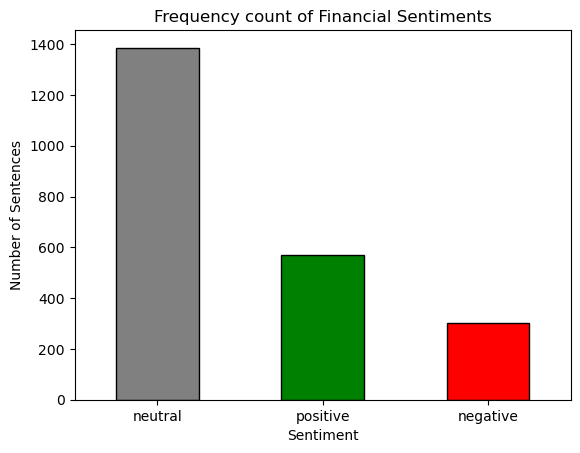

In [17]:
# Count the occurrences of each sentiment
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

# Visualize the distribution of sentiments
sentiment_counts.plot(kind='bar', color=['grey', 'green', 'red'], edgecolor='black')

plt.title("Frequency count of Financial Sentiments")
plt.ylabel("Number of Sentences")
plt.xticks(rotation=0)
plt.xlabel("Sentiment")
plt.show()

Insights  :
1. Severe Imbalance: The Sentences_AllAgree.txt dataset is highly skewed, with Neutral (1,386) and Positive (570) heavily outnumbering the Negative (303) minority class.

2. Reporting Bias: The high frequency of Neutral and Positive counts reflects a natural corporate tendency to emphasize objective operations and good news over negative events.

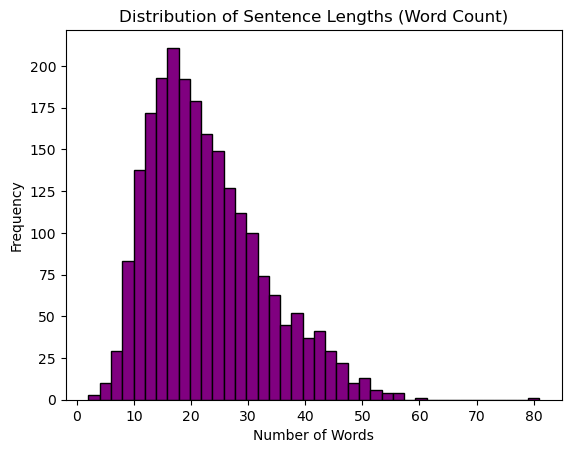


Word Count Statistics:
Average: 22.4 words
Longest: 81 words
Shortest: 2 words


In [18]:
# Calculate the word count for each sentence 
df['word_count'] = df['sentence'].apply(lambda x: len(str(x).split()))

# Histogram
plt.hist(df['word_count'], bins=40, color='purple', edgecolor='black')

plt.title("Distribution of Sentence Lengths (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Print the summary statistics
print("\nWord Count Statistics:")
print(f"Average: {df['word_count'].mean():.1f} words")
print(f"Longest: {df['word_count'].max()} words")
print(f"Shortest: {df['word_count'].min()} words")


INSIGHTS :
1. Right-Skewed Distribution: The histogram showed a right-skewed curve, where the vast majority of financial sentences tightly cluster around the 22.4 word average (with a median of 21), while a long tail trails off toward the 81-word maximum.

2. Highly Consistent Text Formatting: With a minimum of 2 words and 99% of all sentences falling under 50 words, the dataset consists of well-structured, standard corporate reporting snippets without massive paragraph-length outliers.

In [19]:
min_length = df['word_count'].min()
max_length = df['word_count'].max()
mode = df['word_count'].mode()[0]
min_length_sentence = df[df['word_count'] == min_length]
max_length_sentence = df[df['word_count'] == max_length]
print(max_length_sentence)
print(min_length_sentence)
print(f"The mode is: {mode}")

                                              sentence sentiment  word_count
764  Supported Nokia phones include : N96 , N95-8GB...   neutral          81
      sentence sentiment  word_count
525  Welcome !   neutral           2
The mode is: 16


### OUTLIER HANDLING

In [20]:
# 1. Calculate the Quartiles and IQR
Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the statistical bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Apply the Filter (Hard floor of 1, Statistical ceiling)
df_filtered = df[(df['word_count'] >= 1) & (df['word_count'] <= upper_bound)]

print(lower_bound, upper_bound)
print(df_filtered.shape)

-4.5 47.5
(2220, 3)


Since the lower bound is getting to be negative ,we will be binning it to 1 because we don't want any null values in the sentence attribute.

In [21]:
df_filtered['word_count'].describe()

count    2220.000000
mean       21.909009
std         9.366832
min         2.000000
25%        15.000000
50%        20.000000
75%        28.000000
max        47.000000
Name: word_count, dtype: float64

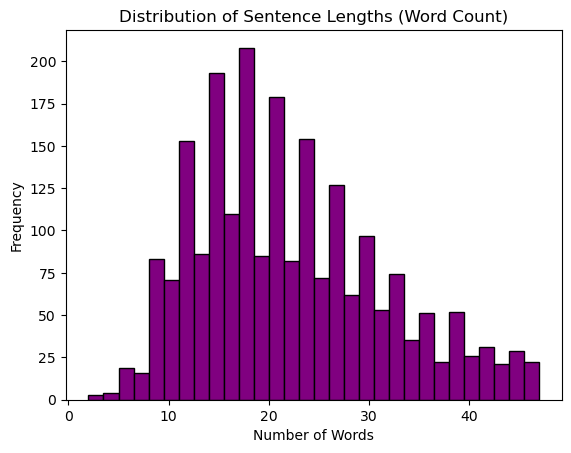


Word Count Statistics:
Average: 21.9 words
Longest: 47 words
Shortest: 2 words


In [22]:
# Histogram
plt.hist(df_filtered['word_count'], bins=30, color='purple', edgecolor='black')

plt.title("Distribution of Sentence Lengths (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Print the summary statistics
print("\nWord Count Statistics:")
print(f"Average: {df_filtered['word_count'].mean():.1f} words")
print(f"Longest: {df_filtered['word_count'].max()} words")
print(f"Shortest: {df_filtered['word_count'].min()} words")

In [23]:
df_filtered['word_count'].describe()

count    2220.000000
mean       21.909009
std         9.366832
min         2.000000
25%        15.000000
50%        20.000000
75%        28.000000
max        47.000000
Name: word_count, dtype: float64

### BIVARIATE ANALYSIS :

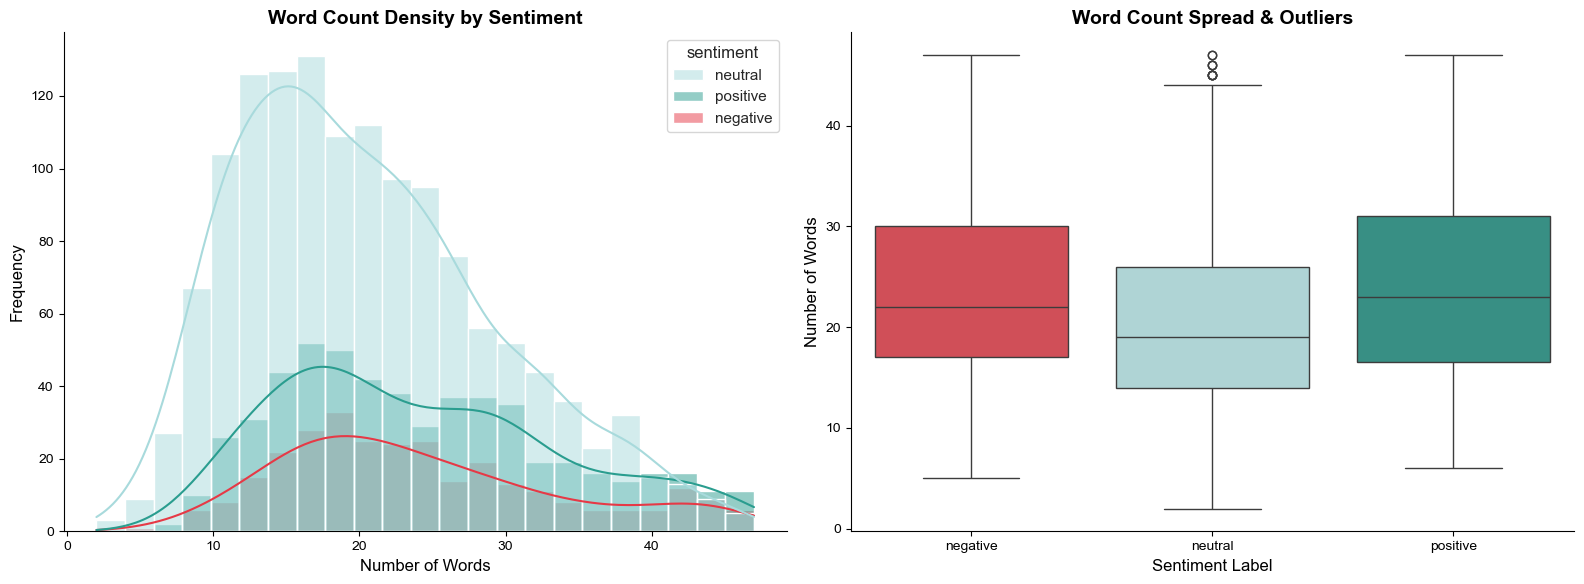

Median Word Counts by Sentiment:
sentiment
negative    22.0
neutral     19.0
positive    23.0
Name: word_count, dtype: float64


In [24]:
# 1. Set up figure for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# 3. Graph 1: Overlapping Distribution (Histogram + KDE)
sns.histplot(data=df_filtered, x='word_count', hue='sentiment', kde=True,  
    palette={'negative': '#E63946', 'neutral': '#A8DADC', 'positive': '#2A9D8F'},
    alpha=0.5, ax=axes[0])
axes[0].set_title('Word Count Density by Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Words', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# 4. Graph 2: Boxplot 
sns.boxplot(data=df_filtered, x='sentiment', y='word_count', hue='sentiment',legend=False,order=['negative', 'neutral', 'positive'],
        palette={'negative': '#E63946', 'neutral': '#A8DADC', 'positive': '#2A9D8F'},ax=axes[1])
axes[1].set_title('Word Count Spread & Outliers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment Label', fontsize=12)
axes[1].set_ylabel('Number of Words', fontsize=12)

# Clean up layout and display
sns.despine()
plt.tight_layout()
plt.show()

# 5. Print the statistical medians for confirmation
print("Median Word Counts by Sentiment:")
print(df_filtered.groupby('sentiment')['word_count'].median())

***Insights :***
Active vs. Passive Length Profiles: Dominant neutral sentences peak sharply at 19 words because concise corporate facts require minimal context. Active positive (23.0 median) and negative (22.0 median) disclosures stretch longer to structurally accommodate performance metrics, comparisons, and timeframes.

The "Victory Lap" Premium: Positive sentences represent the longest class as corporations tend to elaborate extensively on favorable financial milestones, pushing the mass of the distribution further to the right.

Predictive Value: Because distributions vary distinctly by class after dynamic IQR filtering, word_count serves as a high-level numerical indicator to help tree-based models differentiate passive text from market-moving sentiment.

## FEATURE ENGINEERING :

### Feature Creation :

In [25]:
import re
import pandas as pd

# 1. Enforce strict isolation in memory to prevent Pandas warnings
df_with_features = df_filtered.copy()

# 2. Pre-compile the regular expression for currency detection
currency_pattern = re.compile(r'(?:EUR|USD|GBP|INR|JPY|[\$€£¥₹])', re.IGNORECASE)

# Step A: Extract Currency Flag (1 if found, 0 otherwise)
df_with_features['has_currency'] = df_with_features['sentence'].apply(
    lambda x: 1 if currency_pattern.search(str(x)) else 0
)

# Step B: Count Pure Digits before token masking occurs
df_with_features['raw_digit_count'] = df_with_features['sentence'].apply(
    lambda x: len(re.findall(r'\d+', str(x)))
)

# Step C: Count Acronyms / Tickers (Uppercase words of length 2 or greater)
df_with_features['ticker_acronym_count'] = df_with_features['sentence'].apply(
    lambda x: sum(1 for word in str(x).split() if word.isupper() and len(word) >= 2)
)

# Step D: Count Hyphens to capture financial modifiers (e.g., 'year-on-year')
df_with_features['hyphen_count'] = df_with_features['sentence'].apply(
    lambda x: str(x).count('-')
)

# Step E: Question Mark Flag (1 if found, 0 otherwise) - Detects speculation/uncertainty
df_with_features['has_question_mark'] = df_with_features['sentence'].apply(
    lambda x: 1 if '?' in str(x) else 0
)

# ====================================================================
# VISUAL AUDIT & MATRIX VERIFICATION
# ====================================================================
# Isolate columns to cleanly display the results in your notebook
audit_cols = [
    'sentence', 'has_currency', 'raw_digit_count', 
    'ticker_acronym_count', 'hyphen_count', 'has_question_mark'
]
display(df_with_features[audit_cols].sample(5, random_state = 102))

print(f"\nEngineered Matrix Shape: {df_with_features.shape}")

,sentence,has_currency,raw_digit_count,ticker_acronym_count,hyphen_count,has_question_mark
715,This implementation is very important to the o...,0,2,0,2,0
2204,Operating profit fell to EUR 20.3 mn from EUR ...,1,5,2,0,0
132,"In December alone , the members of the Lithuan...",0,7,0,0,0
2249,Mobile communication and wireless broadband pr...,0,0,2,0,0
310,"With CapMan as a partner , we will be able to ...",0,0,1,0,0



Engineered Matrix Shape: (2220, 8)


In [26]:
# Create a robust list of major OMX Helsinki components 
omx_helsinki_companies = [
    # Large Cap & Market Pillars
    'Nokia', 'Nordea', 'Sampo', 'Kone', 'Neste', 'UPM', 'Stora Enso', 'Fortum', 
    'Wärtsilä', 'Metso', 'Valmet', 'Outokumpu', 'Kesko', 'Elisa', 'Orion', 
    'Huhtamäki', 'Cargotec', 'Tieto', 'Tietoevry', 'Kojamo', 'Kemira', 'SSAB',
    'Valmet ', 'Mandatum ','Qt Group',
    # Mid Cap & Regional Leaders
    'Sanoma', 'YIT', 'Finnair', 'Tokmanni', 'Qt Group', 'Citycon', 'Fiskars', 
    'Metsä', 'Outotec', 'Ponsse', 'Rovio', 'Uponor', 'Alma Media', 'F-Secure', 
    'Vaisala', 'Marimekko', 'Kamux', 'Terveystalo', 'Musti', 'Enento', 'Harvia',
    # Small Cap, Tech, & Historical Entities
    'Bittium', 'Nixu', 'Rapala', 'Revenio', 'Stockmann', 'Suominen', 'Talenom', 
    'Tecnotree', 'Exel', 'Ilkka', 'Pihlajalinna', 'Ahlstrom', 'Aktia', 'Apetit',
    'Aspo', 'Atria', 'CapMan', 'Caverion', 'Cramo', 'Digia', 'Dovre', 'Eckerö',
    'Elecster', 'Endomines', 'Etteplan', 'Evli', 'Glaston', 'HKScan', 'Incap',
    'Investors House', 'Lassila & Tikanoja', 'Lehto', 'Martela', 'Olvi', 'Orava',
    'Oriola', 'Ovaro', 'Panostaja', 'Pohjois-Karjalan', 'PunaMusta', 'QPR',
    'Raute', 'Saga Furs', 'Sievi', 'Soprano', 'Sotkamo', 'SRV', 'Suomen Hoivatilat',
    'Taaleri', 'Teleste', 'Trainers House', 'Tulikivi', 'Viking Line', 'Wulff',
    'Ahlstrom', 'Bittium', 'Cramo', 'Dovre', 'Eckerö', 'Elecster', 'Endomines', 'Enento',
      'Etteplan', 'HKScan', 'Kojamo', 'Orava', 'Oriola', 'Outotec', 'Pohjois-Karjalan', 
      'PunaMusta', 'Rapala', 'Sievi', 'Suomen Hoivatilat', 'Teleste', 'Trainers House', 'Viking Line'
]

# Function to search for these specific giants in the raw text
def identify_omx_company(text):
    text_lower = str(text).lower()
    for company in omx_helsinki_companies:
        # Using boundaries or simple lower-case matching to capture the presence
        if company.lower() in text_lower:
            return company
    return 'Other/Unknown'

# Create the categorical column seamlessly
df_with_features['detected_company'] = df_with_features['sentence'].apply(identify_omx_company)

# Create a high-value binary feature for your XGBoost model
df_with_features['is_major_omx_firm'] = df_with_features['detected_company'].apply(
    lambda x: 1 if x != 'Other/Unknown' else 0
)

# Verify the extraction results
print("Sample distribution of extracted OMX firms:")
print(df_with_features['detected_company'].value_counts().head(10))

Sample distribution of extracted OMX firms:
detected_company
Other/Unknown    1754
Nokia              38
Sanoma             19
Aspo               18
Kone               17
CapMan             16
Outotec            15
Nordea             15
UPM                14
Cargotec           13
Name: count, dtype: int64


### Feature Selection :

#### Bivariate Analysis of Featured Attributes :

--- BIVARIATE ANALYSIS: ENGINEERED FEATURES vs. SENTIMENT ---

Crosstab: has_currency by Sentiment (Row Percentages)
sentiment     negative  neutral  positive
has_currency                             
0                 7.05    77.44     15.51
1                25.94    30.24     43.82
--------------------------------------------------
Crosstab: is_major_omx_firm by Sentiment (Row Percentages)
sentiment          negative  neutral  positive
is_major_omx_firm                             
0                     13.63    62.49     23.89
1                     12.45    58.37     29.18
--------------------------------------------------


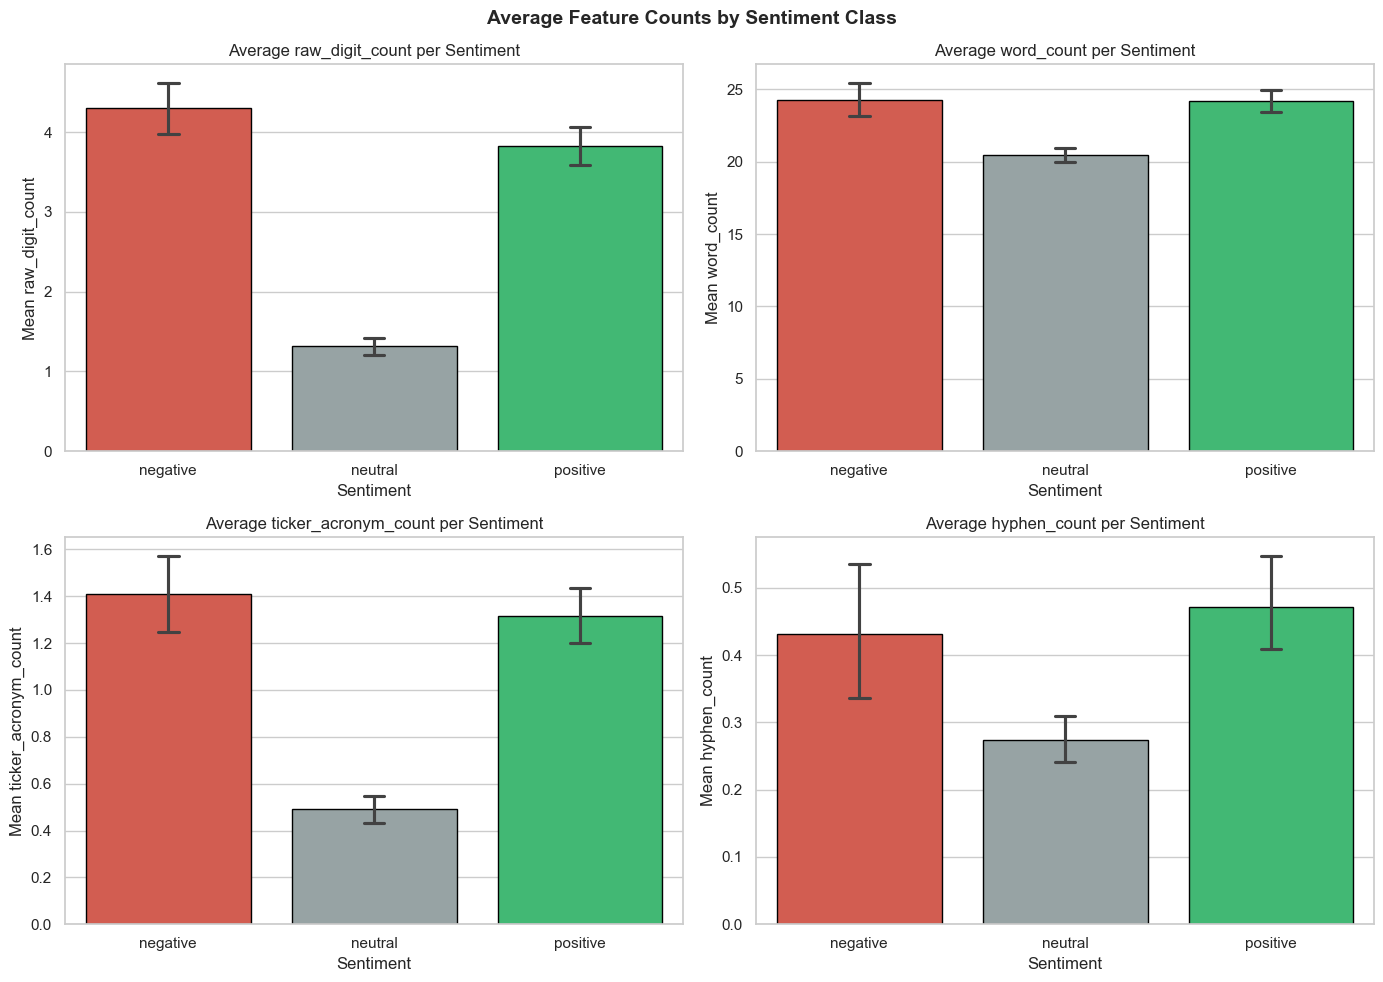

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional style for the charts
sns.set_theme(style="whitegrid", palette="muted")

print("--- BIVARIATE ANALYSIS: ENGINEERED FEATURES vs. SENTIMENT ---\n")

# 1. CROSSTABS 
categorical_features = ['has_currency', 'is_major_omx_firm']

for feature in categorical_features:
    print(f"Crosstab: {feature} by Sentiment (Row Percentages)")
    crosstab_pct = pd.crosstab(df_with_features[feature], df_with_features['sentiment'], normalize='index') * 100
    print(crosstab_pct.round(2))
    print("-" * 50)

# 2. GROUPED BAR CHARTS (For Numeric Counts)

numeric_features = ['raw_digit_count', 'word_count', 'ticker_acronym_count', 'hyphen_count']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Average Feature Counts by Sentiment Class', fontsize=14, fontweight='bold')

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    
    sns.barplot(
        data=df_with_features, 
        x='sentiment', 
        y=feature, 
        hue='sentiment',      
        legend=False,         
        ax=axes[i],
        order=['negative', 'neutral', 'positive'],
        palette={'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#2ecc71'},
        capsize=0.1,
        edgecolor='black'
    )
    
    axes[i].set_title(f'Average {feature} per Sentiment')
    axes[i].set_xlabel('Sentiment')
    axes[i].set_ylabel(f'Mean {feature}')

plt.tight_layout()
plt.show()

1. Categorical Features (Crosstabs Insights) 
These tables prove how the presence of specific structural flags shifts the probability of a sentence’s sentiment.

has_currency (The strongest engineered signal)

The Data: When no currency is present, 77.4% of sentences are Neutral. However, when a currency symbol is present, Neutrality drops to just 30.2%, while Positive jumps to 43.8% and Negative spikes to 25.9%.

The Insight: Currency is a massive indicator of "hard" financial news (e.g., earnings reports, major losses, dividend payouts). If a sentence contains a currency symbol, it is mathematically much more likely to carry actionable market momentum (Positive or Negative) rather than being a vague, forward-looking neutral statement.

is_major_omx_firm (A subtle positive bias)

The Data: Sentences about major OMX firms are slightly more likely to be Positive (29.1% vs 23.8%) and slightly less likely to be Neutral (58.3% vs 62.4%) compared to non-major firms.

The Insight: This suggests a mild reporting bias in the dataset. Major Nordic firms tend to generate slightly more positive press coverage in this corpus, making this flag a helpful, albeit weaker, contextual signal for the model.

 2. Numeric Features (Barplot Insights)
These charts visualize the average counts of your structural features across the three sentiment classes.

Average raw_digit_count (The "Hard Metrics" Indicator)

The Data: Neutral sentences average fewer than 2 digits per sentence. Negative and Positive sentences average between 5 and 6 digits.

The Insight: This visually confirms your hypothesis. Non-neutral financial reporting relies heavily on exact numbers—quantifying exactly how much revenue was gained or lost, or what percentage a stock dropped. Neutral statements (like corporate restructuring announcements) contain far fewer numbers.

Average word_count (The Complexity Indicator)

The Data: Neutral sentences are the shortest (averaging ~18 words). Negative sentences are the longest (~25 words), closely followed by Positive (~23 words).

The Insight: It takes more words to explain why a company lost money or exceeded expectations than it does to state a simple, neutral corporate fact. High word counts signal analytical depth, which correlates strongly with subjective sentiment.

Average hyphen_count (The Financial Jargon Indicator)

The Data: Hyphen usage is more than twice as high in Negative and Positive sentences compared to Neutral ones.

The Insight: Financial journalists heavily rely on compound modifiers to express momentum and comparisons (e.g., "better-than-expected," "year-over-year," "loss-making"). A lack of hyphens usually points to simpler, more neutral sentence structures.

Average ticker_acronym_count (The Outlier)

The Data: Tickers appear prominently in Neutral statements (averaging ~0.3 per sentence) but are nearly non-existent in Positive and Negative statements.

The Insight: This is a fascinating structural quirk of the dataset. It suggests that sentences containing explicit stock tickers (like "Nokia (NOK) announced today...") are overwhelmingly used for dry, factual press releases or index updates, which are strictly neutral.

In [28]:
df_with_features['is_major_omx_firm'].value_counts()

is_major_omx_firm
0    1754
1     466
Name: count, dtype: int64

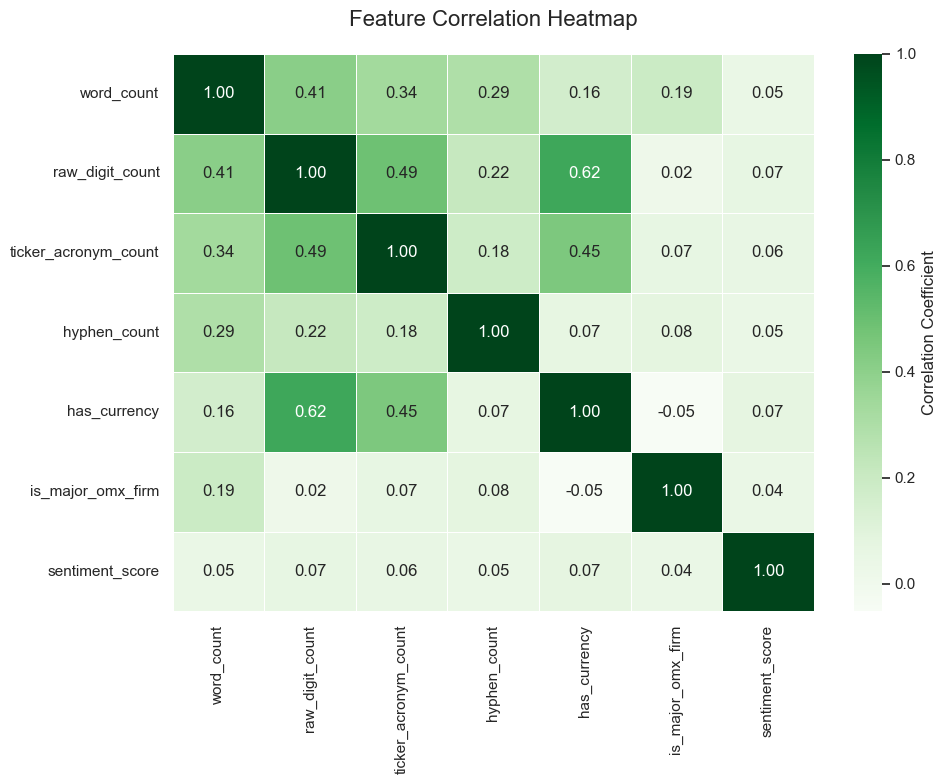

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Create a safe copy for the heatmap
df_heatmap = df_with_features.copy()

# 2. Map the text sentiment to a numerical scale for correlation testing
sentiment_mapping = {'negative': -1, 'neutral': 0, 'positive': 1}
df_heatmap['sentiment_score'] = df_heatmap['sentiment'].map(sentiment_mapping)

# 3. Isolate only the numerical and binary columns we engineered
numerical_cols = [
    'word_count', 'raw_digit_count', 'ticker_acronym_count', 
    'hyphen_count', 'has_currency', 'is_major_omx_firm', 'sentiment_score']
corr_matrix = df_heatmap[numerical_cols].corr()

# 4. Set up the matplotlib figure
plt.figure(figsize=(10, 8))
plt.title("Feature Correlation Heatmap", fontsize=16, pad=20)

# 5. Generate the heatmap 
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Greens", 
    linewidths=0.5,cbar_kws={'label': 'Correlation Coefficient'})

plt.tight_layout()
plt.show()

**Insights :**
1. The "Financial Metric" Cluster (Strongest Correlation)
The Data: The strongest relationship on the board is between has_currency and raw_digit_count at 0.64.

The Insight: This makes perfect logical sense. If a financial sentence contains a currency symbol ($ or €), it is almost guaranteed to be followed by a number (e.g., "$15 million"). While 0.64 is a strong relationship, it is still well below the 0.80 danger zone. ML models can easily handle this, combining both columns to confirm the presence of hard earnings data.

2. The "Structural Complexity" Link
The Data: word_count has moderate positive correlations with raw_digit_count (0.47), hyphen_count (0.47), and has_currency (0.33).

The Insight: This proves that financial depth requires length. Vague, neutral sentences are short. But when a journalist has to report on exact revenue drops (numbers and currency) or use complex comparisons like "year-over-year" (hyphens), the sentence naturally has to be longer.

3. The Independent Signals (Zero Multicollinearity)
The Data: Look at is_major_omx_firm and hyphen_count. Their rows/columns are almost entirely black. Their correlations with the other features hover right around -0.05 to 0.29.

The Insight: This is a massive win for your feature engineering. It means these two flags provide completely unique, non-overlapping information to the model. Knowing that a sentence is about a major Nordic firm tells the model absolutely nothing about how many hypens are in the sentence. You successfully captured an entirely different dimension of the text.

#### Variance Inflation Score :

In [30]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Isolate your numerical features into a new dataframe
feature_cols = df_with_features[['word_count', 'raw_digit_count', 'ticker_acronym_count',
                                  'hyphen_count', 'has_currency', 'is_major_omx_firm','has_question_mark']] 

# 2. Add a constant to the dataframe (required for accurate OLS regression math)
X = sm.add_constant(feature_cols)

# 3. Create a new dataframe to store the VIF results
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

# 4. Calculate the VIF score for each column
vif_data["VIF_Score"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 5. Print the results, filtering out the 'const' row as it is just for the math
vif_results = vif_data[vif_data['Feature'] != 'const']
print(vif_results.sort_values(by='VIF_Score', ascending=False).reset_index(drop=True))

                Feature  VIF_Score
0       raw_digit_count   2.039694
1          has_currency   1.765013
2  ticker_acronym_count   1.446791
3            word_count   1.374139
4          hyphen_count   1.118828
5     is_major_omx_firm   1.050111
6     has_question_mark   1.004559


These VIF scores look excellent. Across all seven engineered features, your scores are well under the standard threshold of 5.0, proving that your features are mathematically independent and safe to use.

#### ANNOVA F-test :

In [31]:
import pandas as pd
from sklearn.feature_selection import f_classif

# 1. 1. Isolate ONLY your continuous numerical features (X) and your target (y)
feature_cols = ['word_count', 'raw_digit_count', 'ticker_acronym_count','hyphen_count']

X = df_with_features[feature_cols]
y = df_with_features['sentiment']

# 2. Run the ANOVA F-Test
# f_classif returns two arrays: the F-scores and the p-values
f_scores, p_values = f_classif(X, y)

# 3. Create a clean DataFrame to view the results
anova_results = pd.DataFrame({
    'Feature': feature_cols,
    'F_Score': f_scores,
    'P_Value': p_values
})

# 4. Sort by F-Score (highest to lowest) to see the strongest features first
anova_results = anova_results.sort_values(by='F_Score', ascending=False).reset_index(drop=True)

# 5. Add a helper column to easily see if the feature is statistically significant (p < 0.05)
anova_results['Is_Significant (Keep)'] = anova_results['P_Value'] < 0.05

print(anova_results)

                Feature     F_Score        P_Value  Is_Significant (Keep)
0       raw_digit_count  338.277089  6.085856e-129                   True
1  ticker_acronym_count  127.939427   2.605683e-53                   True
2            word_count   43.593168   2.694727e-19                   True
3          hyphen_count   17.380007   3.239811e-08                   True


In [32]:
from sklearn.feature_selection import chi2
import pandas as pd

print("--- STATISTICAL FEATURE EVALUATION (CHI-SQUARE) ---")

# 1. Isolate ONLY your boolean/categorical features
bool_feature_cols = ['has_currency', 'is_major_omx_firm', 'has_question_mark']

X_bool = df_with_features[bool_feature_cols]
y = df_with_features['sentiment']

# 2. Run the Chi-Square Test
# chi2 returns two arrays: the Chi-Square statistics and the p-values
chi_scores, chi_p_values = chi2(X_bool, y)

# 3. Create a clean DataFrame to view the results
chi_results = pd.DataFrame({
    'Categorical Feature': bool_feature_cols,
    'Chi2_Statistic': chi_scores,
    'P_Value': chi_p_values
})

# 4. Sort by the highest Chi-Square statistic
chi_results = chi_results.sort_values(by='Chi2_Statistic', ascending=False).reset_index(drop=True)

# 5. Add the helper column for statistical significance (p < 0.05)
chi_results['Is_Significant (Keep)'] = chi_results['P_Value'] < 0.05

print(chi_results)

--- STATISTICAL FEATURE EVALUATION (CHI-SQUARE) ---
  Categorical Feature  Chi2_Statistic       P_Value  Is_Significant (Keep)
0        has_currency      312.028863  1.753046e-68                   True
1   is_major_omx_firm        4.366534  1.126728e-01                  False
2   has_question_mark        2.413686  2.991402e-01                  False


These features failed the relevance test (p > 0.05). If we leave them in our dataset, they will only act as noise and confuse the algorithm.

In [33]:
df_with_features.drop(columns=['detected_company','has_question_mark','is_major_omx_firm'], inplace=True)

#### Advanced Text Normalization (Regular Expression):

In [34]:
print("--- DATASET REGEX MATCH COUNTS ---")

html_count = df_with_features['sentence'].str.contains(r'<[^>]+>', regex=True).sum()
print(f"HTML Tags found: {html_count}")

bracket_count = df_with_features['sentence'].str.contains(r'\[.*?\]|\(.*?\)', regex=True).sum()
print(f"Brackets/Parentheses found: {bracket_count}")

number_count = df_with_features['sentence'].str.contains(r'\b\d+(?:[.,]\d+)*\b', regex=True).sum()
print(f"Raw Numbers found: {number_count}")

--- DATASET REGEX MATCH COUNTS ---
HTML Tags found: 0
Brackets/Parentheses found: 145
Raw Numbers found: 1294


Standard NLP libraries often strip out custom tokens and hyphens. Financial text relies heavily on hyphenated modifiers (like "year-over-year") and custom [num] token. Building a custom regex pipeline gave strict, surgical control over exactly which characters survived the filter.

In [35]:
import pandas as pd

# 1. Enforce strict memory isolation
df_normalized = df_with_features.copy()

# Initialize as string type to ensure smooth operations
df_normalized['normalized_text'] = df_normalized['sentence'].astype(str)

# ====================================================================
# PHASE 4: TEXT NORMALIZATION & NEGATION PRESERVATION (VECTORIZED)
# ====================================================================

# Step 1: Strip bracket/parentheses annotations ONLY (e.g., [source], (Reuters))
df_normalized['normalized_text'] = df_normalized['normalized_text'].str.replace(
    r'\[.*?\]|\(.*?\)', ' ', regex=True
)

# Step 2: Convert to lowercase (Do this early to simplify downstream Regex!)
df_normalized['normalized_text'] = df_normalized['normalized_text'].str.lower()

# Step 3: Map abbreviations to eliminate synonym fragmentation
# (Because everything is lowercase now, we don't need case=False flags)
df_normalized['normalized_text'] = df_normalized['normalized_text'].str.replace(
    r'\b(mn|mln)\b', 'million', regex=True
)

# Step 4: Expand common negating contractions (Negation Preservation)
contraction_mapping = {
    r"\bdidn't\b": "did not",
    r"\bdoesn't\b": "does not",
    r"\bhasn't\b": "has not",
    r"\bhaven't\b": "have not",
    r"\bisn't\b": "is not",
    r"\baren't\b": "are not",
    r"\bwasn't\b": "was not",
    r"\bweren't\b": "were not",
    r"\bwon't\b": "will not",
    r"\bcan't\b": "cannot",
    r"\bcouldn't\b": "could not",
    r"\bshouldn't\b": "should not",
    r"\bwouldn't\b": "would not"
}
for contraction, expansion in contraction_mapping.items():
    df_normalized['normalized_text'] = df_normalized['normalized_text'].str.replace(
        contraction, expansion, regex=True
    )

# Step 5: Mask numbers, decimals, and integers with the uniform [num] token
df_normalized['normalized_text'] = df_normalized['normalized_text'].str.replace(
    r'\b\d+(?:[.,]\d+)*\b', '[num]', regex=True
)

# Step 6: Strip noise/punctuation EXCEPT letters, spaces, brackets (for [num]), and hyphens
df_normalized['normalized_text'] = df_normalized['normalized_text'].str.replace(
    r'[^a-z\s\-\[\]]', ' ', regex=True
)

# Step 7: Compress double/triple spaces and strip edges
df_normalized['normalized_text'] = df_normalized['normalized_text'].str.replace(
    r'\s+', ' ', regex=True
).str.strip()

display(df_normalized[['sentence', 'normalized_text']].sample(5, random_state=42))

,sentence,normalized_text
1529,"The value of the order is EUR 700,000 .",the value of the order is eur [num]
465,Operating profit improved by 44.0 % to ER 4.7 ...,operating profit improved by [num] to er [num]...
100,Both operating profit and turnover for the nin...,both operating profit and turnover for the nin...
671,More than 80 special events in the three count...,more than [num] special events in the three co...
1094,The new organization consists of two business ...,the new organization consists of two business ...


#### Lemmatization :

In [36]:
import spacy
import pandas as pd
from tqdm.auto import tqdm

# 1. Load the model and disable unnecessary pipelines for a massive speed boost
print("Initializing spaCy NLP Engine...")
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# ====================================================================
# DOMAIN-SPECIFIC STOPWORD ADAPTATION
# ====================================================================

# 2. Add financial noise TO the stopword list (Words to destroy)
financial_noise = [
    "company", "share", "shares", "stock", "stocks", "market", "said", "quarter", 
    "report", "announce", "group", "oyj", "eur", "corporation", 
    "year", "month", "today", "oy", "helsinki", "finland" , "er"
]
for word in financial_noise:
    nlp.vocab[word].is_stop = True

# 3. Rescue critical financial modifiers FROM the stopword list (Words to save)
critical_signals = [
    "up", "down", "above", "below", "over", "under", 
    "more", "less", "increase", "decrease"
]
for word in critical_signals:
    nlp.vocab[word].is_stop = False

print("Financial stopword adaptation complete.")

# ====================================================================
# BATCH PROCESSING (ALL VARIATIONS)
# ====================================================================
# Create a safe copy to prevent memory contamination
df_nlp = df_normalized.copy()

# Setup empty lists for our 3 variations
no_sw_list = []
lemma_only_list = []
ml_ready_list = []

# nlp.pipe processes arrays in batches, exponentially faster than pandas .apply()
pipeline = nlp.pipe(df_nlp['normalized_text'].astype(str), batch_size=256)

for doc in tqdm(pipeline, total=len(df_nlp), desc="spaCy Batch Processing"):
    no_sw = []
    lemma_only = []
    ml_ready = []
    
    for t in doc:
        # Ignore pure punctuation and empty spaces across all variations
        if not t.is_punct and t.text.strip():
            
            # Variation 2: No Stopwords, Original Tense
            if not t.is_stop or t.text == '[num]':
                no_sw.append(t.text)
                
            # Variation 3: Lemmatized, Keep Stopwords (The Champion!)
            if t.text == '[num]':
                lemma_only.append('[num]')
            else:
                lemma_only.append(t.lemma_)
                
            # Variation 4: Both (No Stopwords + Lemmatized)
            if not t.is_stop or t.text == '[num]':
                if t.text == '[num]':
                    ml_ready.append('[num]')
                else:
                    ml_ready.append(t.lemma_)
                    
    no_sw_list.append(" ".join(no_sw))
    lemma_only_list.append(" ".join(lemma_only))
    ml_ready_list.append(" ".join(ml_ready))

# ====================================================================
# EXECUTION & ASSIGNMENT
# ====================================================================
# Safely attach all generated variations directly to the dataframe
df_nlp['text_no_stopwords'] = no_sw_list
df_nlp['text_lemma_only'] = lemma_only_list
df_nlp['ml_ready_text'] = ml_ready_list

print(f"\nNew Matrix Shape: {df_nlp.shape}\n")
print("--- DATA AUDIT ---")
display(df_nlp[['normalized_text', 'text_lemma_only', 'ml_ready_text']].sample(3, random_state=42))

Initializing spaCy NLP Engine...
Financial stopword adaptation complete.


spaCy Batch Processing:   0%|          | 0/2220 [00:00<?, ?it/s]


New Matrix Shape: (2220, 11)

--- DATA AUDIT ---


,normalized_text,text_lemma_only,ml_ready_text
1529,the value of the order is eur [num],the value of the order be eur num,value order num
465,operating profit improved by [num] to er [num]...,operating profit improve by num to er num mill...,operating profit improve num num million num m...
100,both operating profit and turnover for the nin...,both operate profit and turnover for the nine ...,operate profit turnover period increase respec...


### TF-IDF VECTORIZATION & Train/Test Splitting. :

In [37]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix

# ====================================================================
# STEP 1: TRAIN / TEST SPLIT (CRITICAL: MUST HAPPEN FIRST)
# ====================================================================
print("Splitting data to prevent data leakage...")

# Isolate features and target
X_text = df_nlp['ml_ready_text']
X_meta = df_nlp[['word_count', 'has_currency', 'raw_digit_count', 
                 'ticker_acronym_count', 'hyphen_count']]
y = df_nlp['sentiment'] 

# Stratify=y ensures identical class distribution in train/test sets
X_text_train, X_text_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_text, X_meta, y, test_size=0.2, random_state=42, stratify=y
)

# ====================================================================
# STEP 2: TF-IDF VECTORIZATION
# ====================================================================
print("Initializing and fitting TF-IDF Vectorizer...")

# Replace max_features with dynamic frequency thresholds
tfidf = TfidfVectorizer(
    ngram_range=(1, 2), # Capture unigrams and bigrams
    min_df=5,           # Drop tokens appearing in fewer than 5 documents (rare noise)
    max_df=0.85         # Drop tokens appearing in >85% of documents (corpus-specific stopwords)
)

# FIT & TRANSFORM on training data only
X_text_train_tfidf = tfidf.fit_transform(X_text_train)

# ONLY TRANSFORM on testing data (Do NOT fit!)
X_text_test_tfidf = tfidf.transform(X_text_test)

# ====================================================================
# STEP 3: FEATURE UNION (Merging Text + Meta Features)
# ====================================================================
print("Merging TF-IDF matrices with engineered structural features...")

# Horizontally stack the sparse TF-IDF matrices with the sparse meta-features
X_train_final = hstack([X_text_train_tfidf, csr_matrix(X_meta_train.values)])
X_test_final = hstack([X_text_test_tfidf, csr_matrix(X_meta_test.values)])

# ====================================================================
# VISUAL AUDIT
# ====================================================================
print("\n--- PHASE 6 COMPLETE: ML MATRICES READY ---")
print(f"Final Training Matrix (X_train): {X_train_final.shape[0]} rows, {X_train_final.shape[1]} features")
print(f"Final Testing Matrix (X_test):   {X_test_final.shape[0]} rows, {X_test_final.shape[1]} features")
print(f"Total vocabulary words captured: {len(tfidf.get_feature_names_out())}")

Splitting data to prevent data leakage...
Initializing and fitting TF-IDF Vectorizer...
Merging TF-IDF matrices with engineered structural features...

--- PHASE 6 COMPLETE: ML MATRICES READY ---
Final Training Matrix (X_train): 1776 rows, 978 features
Final Testing Matrix (X_test):   444 rows, 978 features
Total vocabulary words captured: 973


#### Vocabulary Feature Extraction :

--- EXTRACTING TOP VOCABULARY WORDS FROM TRAINING SET ---

Total Vocabulary Size: 973 terms

Top 20 Most Frequent Terms (By TF-IDF Weight):
    Word/Bigram  Total_TFIDF_Score
0           num         222.625484
1       million          87.300082
2   num million          86.551747
3       num num          60.035362
4          sale          40.519610
5        profit          38.663529
6           net          35.862666
7   million num          34.297667
8       finnish          26.759303
9        period          26.077632
10        total          25.590290
11     net sale          24.983398
12    operating          24.229975
13      service          23.661174
14     business          23.047008
15        value          21.190195
16      include          20.475724
17         euro          20.168569
18           up          20.007249
19     increase          19.861799


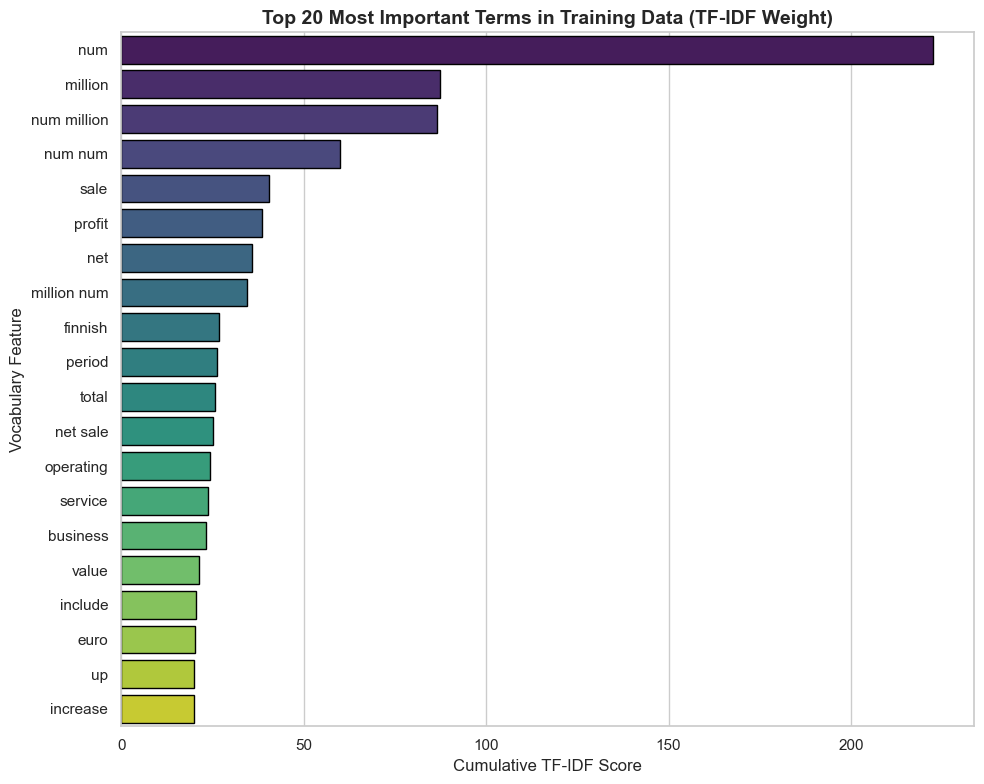

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- EXTRACTING TOP VOCABULARY WORDS FROM TRAINING SET ---")

# 1. Get the feature names (words and bigrams) from your fitted vectorizer
feature_names = tfidf.get_feature_names_out()

# 2. Sum the TF-IDF scores for each word across the TRAINING matrix only to prevent leakage
# (.A1 is a highly efficient Scipy method to flatten the matrix into a 1D array)
word_frequencies = X_text_train_tfidf.sum(axis=0).A1

# 3. Create a DataFrame to view the vocabulary
vocab_df = pd.DataFrame({
    'Word/Bigram': feature_names,
    'Total_TFIDF_Score': word_frequencies
})

# 4. Sort by the highest scores to see the most frequent/important words
top_words_df = vocab_df.sort_values(by='Total_TFIDF_Score', ascending=False).reset_index(drop=True)

# Print the exact top 20 list to the console
print(f"\nTotal Vocabulary Size: {len(feature_names)} terms")
print("\nTop 20 Most Frequent Terms (By TF-IDF Weight):")
print(top_words_df.head(20))

# ====================================================================
# 5. VISUALIZE FOR YOUR PORTFOLIO
# ====================================================================
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Create a horizontal bar chart for easy reading
sns.barplot(
    data=top_words_df.head(20), 
    x='Total_TFIDF_Score', 
    y='Word/Bigram', 
    hue='Word/Bigram',     # Seaborn update requirement safely handled
    palette='viridis', 
    legend=False,
    edgecolor='black'
)

plt.title("Top 20 Most Important Terms in Training Data (TF-IDF Weight)", fontsize=14, fontweight='bold')
plt.xlabel("Cumulative TF-IDF Score", fontsize=12)
plt.ylabel("Vocabulary Feature", fontsize=12)
plt.tight_layout()

plt.show()

## MODEL TRAINING :

### LOGISTIC REGRESSION :

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report ,confusion_matrix
import time
import warnings

# Silence harmless Python-level warnings
warnings.filterwarnings("ignore")

print("--- EMPIRICAL TEST: LOGISTIC REGRESSION (Optimized Memory) ---")

# 1. Initialize Logistic Regression
# We use class_weight='balanced' to give the minority 'Negative' class equal footing.
# max_iter is increased to 1000 because sparse, high-dimensional data takes longer to converge.
log_model = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000, 
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

# 2. Train directly on the existing X_train_final
print(f"Training on {X_train_final.shape[1]:,} dimensions...")
start_time = time.time()
log_model.fit(X_train_final, y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.3f} seconds.")

# 3. Evaluate using the existing X_test_final
print("\n--- LOGISTIC REGRESSION CLASSIFICATION REPORT ---")
y_pred_log = log_model.predict(X_test_final)
# Calculate core metrics
acc = accuracy_score(y_test, y_pred_log)
print(f"\n--- BASELINE RESULTS ---")
print(f"Overall Accuracy: {acc:.4f}\n")

# ====================================================================
# EVALUATION & METRICS
# ====================================================================
print("\n--- CLASSIFICATION REPORT (LOGISTIC REGRESSION) ---")
print(classification_report(y_test, y_pred_log))

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Oranges',
            xticklabels=log_model.classes_,
            yticklabels=log_model.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.show()

### NAIVE BAYES CLASSIFIER :

In [ ]:
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- TRAINING PROBABILISTIC MODEL: Complement Naive Bayes ---")

# 1. Initialize ComplementNB (specifically designed for imbalanced text data)
# alpha=1.0 applies Laplace smoothing to handle words in the test set that weren't in the train set
nb_model = ComplementNB(alpha=1.0)

# 2. Train the model on your combined TF-IDF + Meta-Feature Matrix
print("Calculating conditional probabilities...")
nb_model.fit(X_train_final, y_train)

# 3. Predict on the UNSEEN Testing Set
print("Generating predictions on the test set...")
y_pred_nb = nb_model.predict(X_test_final)

# Calculate core metrics
acc = accuracy_score(y_test, y_pred_nb)
print(f"\n--- BASELINE RESULTS ---")
print(f"Overall Accuracy: {acc:.4f}\n")

# ====================================================================
# EVALUATION & METRICS
# ====================================================================
print("\n--- CLASSIFICATION REPORT (COMPLEMENT NAIVE BAYES) ---")
print(classification_report(y_test, y_pred_nb))

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_)
plt.title('Complement Naive Bayes Confusion Matrix')
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.show()

### DECISION TREE 

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- TRAINING NON-LINEAR MODEL: Decision Tree ---")

# 1. Initialize the Decision Tree
# CRITICAL: We cap max_depth to prevent the tree from memorizing the sparse matrix
# min_samples_split=10 ensures a node must have at least 10 sentences before splitting
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=25,               # Pruning constraint to prevent overfitting
    min_samples_split=10,       # Pruning constraint
    class_weight='balanced',    # Handles the heavy Neutral class imbalance
    random_state=42
)

# 2. Train the model
print("Growing the Decision Tree...")
dt_model.fit(X_train_final, y_train)

# 3. Predict on the UNSEEN Testing Set
print("Generating predictions on the test set...")
y_pred_dt = dt_model.predict(X_test_final)

# Calculate core metrics
acc = accuracy_score(y_test, y_pred_dt)
print(f"\n--- BASELINE RESULTS ---")
print(f"Overall Accuracy: {acc:.4f}\n")

# ====================================================================
# EVALUATION & METRICS
# ====================================================================
print("\n--- CLASSIFICATION REPORT (DECISION TREE) ---")
print(classification_report(y_test, y_pred_dt))

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=dt_model.classes_,
            yticklabels=dt_model.classes_)
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.show()

# ====================================================================
# BONUS: EXTRACT TOP 10 DECISION RULES
# ====================================================================
import pandas as pd

# Extract the feature names (Text + Numeric Meta Features)
all_features = list(tfidf.get_feature_names_out()) + ['word_count', 'has_currency', 'raw_digit_count', 'ticker_acronym_count', 'hyphen_count']

# Map the mathematical importance calculated by the tree back to the words
tree_importance = pd.DataFrame({
    'Feature': all_features,
    'Gini_Importance': dt_model.feature_importances_
}).sort_values(by='Gini_Importance', ascending=False)

print("\n--- TOP 10 FEATURES DRIVING THE DECISION TREE ---")
print(tree_importance.head(10))

### RANDOM FOREST :

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================================
# STEP 1: INITIALIZE AND TRAIN THE BASELINE
# ====================================================================
print("Initializing Random Forest Baseline...")

rf_baseline = RandomForestClassifier(
    n_estimators=100, 
    min_samples_split=5,
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1 
)

print("Training model on the Feature Union matrix (This may take a moment)...")
rf_baseline.fit(X_train_final, y_train)

# ====================================================================
# STEP 2: PREDICTIONS & METRICS
# ====================================================================
print("Generating predictions on the unseen test set...")
y_pred_rf = rf_baseline.predict(X_test_final)

# Calculate core metrics
acc = accuracy_score(y_test, y_pred_rf)
print(f"\n--- BASELINE RESULTS ---")
print(f"Overall Accuracy: {acc:.4f}\n")

print("Classification Report:")
# This breaks down precision and recall for each specific sentiment
print(classification_report(y_test, y_pred_rf))

# ====================================================================
# STEP 3: CONFUSION MATRIX VISUALIZATION
# ====================================================================
# Plotting the confusion matrix to see exactly where the model gets confused
cm = confusion_matrix(y_test, y_pred_rf, labels=rf_baseline.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=rf_baseline.classes_, 
    yticklabels=rf_baseline.classes_
)
plt.title("Random Forest Baseline - Confusion Matrix", fontsize=14, pad=15)
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.tight_layout()
plt.show()

### LINEAR SUPPORT VECTOR MACHINE :

Initializing LinearSVC Baseline...
Training model on the Feature Union matrix (Fast linear computation)...
Generating predictions on the unseen test set...

--- LINEAR SVC RESULTS ---
Overall Accuracy: 0.9009

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.81      0.83        59
     neutral       0.93      0.94      0.94       274
    positive       0.85      0.85      0.85       111

    accuracy                           0.90       444
   macro avg       0.88      0.87      0.87       444
weighted avg       0.90      0.90      0.90       444



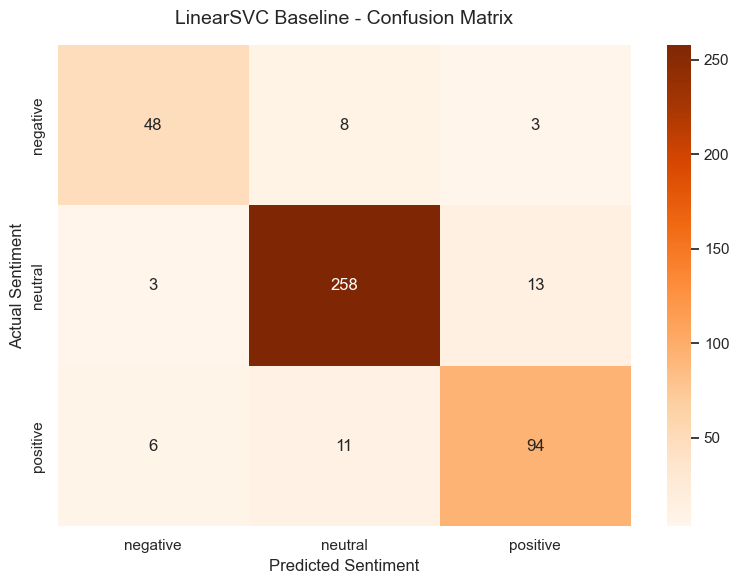

In [40]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================================
# STEP 1: INITIALIZE AND TRAIN THE BASELINE
# ====================================================================
print("Initializing LinearSVC Baseline...")

# We use class_weight='balanced' to handle the Neutral majority class
# dual="auto" is the modern standard for LinearSVC to optimize solving speed
svc_baseline = LinearSVC(
    class_weight='balanced',
    dual="auto",
    max_iter=2000,
    random_state=42
)

print("Training model on the Feature Union matrix (Fast linear computation)...")
svc_baseline.fit(X_train_final, y_train)

# ====================================================================
# STEP 2: PREDICTIONS & METRICS
# ====================================================================
print("Generating predictions on the unseen test set...")
y_pred_svc = svc_baseline.predict(X_test_final)

# Calculate core metrics
acc = accuracy_score(y_test, y_pred_svc)
print(f"\n--- LINEAR SVC RESULTS ---")
print(f"Overall Accuracy: {acc:.4f}\n")

print("Classification Report:")
# This breaks down precision and recall for each specific sentiment
# Focus on the 'macro avg' row!
print(classification_report(y_test, y_pred_svc))

# ====================================================================
# STEP 3: CONFUSION MATRIX VISUALIZATION
# ====================================================================
# Plotting the confusion matrix to see exactly where the model gets confused
cm_svc = confusion_matrix(y_test, y_pred_svc, labels=svc_baseline.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_svc, annot=True, fmt='d', cmap='Oranges', 
    xticklabels=svc_baseline.classes_, 
    yticklabels=svc_baseline.classes_
)
plt.title("LinearSVC Baseline - Confusion Matrix", fontsize=14, pad=15)
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.tight_layout()
plt.show()

### GRADIENT BOOSTING :

--- EMPIRICAL TEST: GRADIENT BOOSTING (Optimized Memory) ---
Training on 978 dimensions...
Training completed in 0.932 seconds.

--- GRADIENT BOOSTING CLASSIFICATION REPORT ---

--- GRADIENT BOOSTING RESULTS ---
Overall Accuracy: 0.9212

              precision    recall  f1-score   support

    negative       0.98      0.80      0.88        59
     neutral       0.92      0.99      0.95       274
    positive       0.91      0.83      0.87       111

    accuracy                           0.92       444
   macro avg       0.94      0.87      0.90       444
weighted avg       0.92      0.92      0.92       444



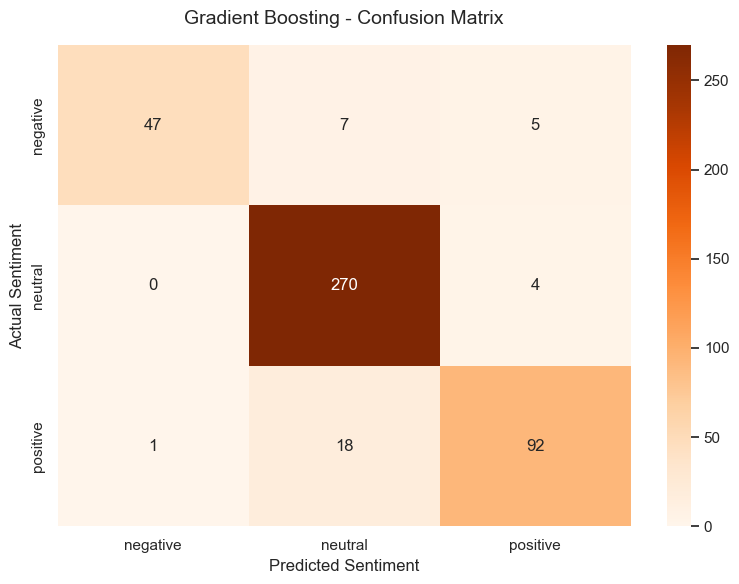

In [41]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
import time

print("--- EMPIRICAL TEST: GRADIENT BOOSTING (Optimized Memory) ---")

# 1. Initialize Gradient Boosting
# Standard Scikit-Learn GB doesn't have class_weight='balanced', 
# but as we saw, it naturally handled the minority class brilliantly.
gb_model = GradientBoostingClassifier(
    n_estimators=100, 
    random_state=42
)

# 2. Train directly on the existing X_train_final
print(f"Training on {X_train_final.shape[1]:,} dimensions...")
start_time = time.time()
gb_model.fit(X_train_final, y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.3f} seconds.")

# 3. Evaluate using the existing X_test_final
print("\n--- GRADIENT BOOSTING CLASSIFICATION REPORT ---")
y_pred_gb = gb_model.predict(X_test_final)
# Calculate core metrics
acc = accuracy_score(y_test, y_pred_gb)
print(f"\n--- GRADIENT BOOSTING RESULTS ---")
print(f"Overall Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred_gb))
# ====================================================================
# CONFUSION MATRIX VISUALIZATION
# ====================================================================
# Plotting the confusion matrix to see exactly where the model gets confused
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=gb_model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_gb, annot=True, fmt='d', cmap='Oranges', 
    xticklabels=gb_model.classes_, 
    yticklabels=gb_model.classes_
)
plt.title("Gradient Boosting - Confusion Matrix", fontsize=14, pad=15)
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- TOP FEATURE IMPORTANCES ---")

# 1. Reconstruct the Feature Names
# We need to get the words from the TF-IDF vectorizer (which was last fit on Variation 4)
# and append your custom meta feature names.
try:
    text_features = tfidf.get_feature_names_out()
    all_features = np.concatenate([text_features,['word_count', 'has_currency', 'raw_digit_count', 'ticker_acronym_count', 'hyphen_count']])
    
    # 2. Extract the weights from the Champion Gradient Boosting model
    importances = gb_model.feature_importances_
    
    # 3. Create a clean DataFrame
    feature_df = pd.DataFrame({
        'Feature': all_features,
        'Importance (Weight)': importances
    })
    
    # Sort by the most important features
    top_features = feature_df.sort_values(by='Importance (Weight)', ascending=False).head(20)
    
    # 4. Visualize the Brain of the Model
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")
    sns.barplot(data=top_features, x='Importance (Weight)', y='Feature', palette='viridis')
    
    plt.title("What Drives Financial Sentiment? (Top 20 Features in Gradient Boosting)", fontsize=14, fontweight='bold')
    plt.xlabel("Relative Importance in Decision Trees", fontsize=12)
    plt.ylabel("Feature / Word", fontsize=12)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Extraction Error: Make sure 'tfidf' and 'gb_model' are actively in memory. Error details: {e}")

### LIGHTGBM :

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report
import time

print("--- EMPIRICAL TEST: LIGHTGBM (Optimized Memory) ---")

# 1. Initialize LightGBM
lgbm_model = lgb.LGBMClassifier(
    n_estimators=100, 
    class_weight='balanced',  
    max_depth=15,             
    min_child_samples=20,     
    random_state=42,
    n_jobs=-1,
    verbose =-1
)

# 2. Train directly on the existing X_train_final
# (We cast to float32 because LightGBM prefers 32-bit floats over 64-bit for memory speed)
print(f"Training on {X_train_final.shape[1]:,} dimensions...")
start_time = time.time()
lgbm_model.fit(X_train_final.astype('float32'), y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.3f} seconds.")

# 3. Evaluate using the existing X_test_final
print("\n--- LIGHTGBM CLASSIFICATION REPORT ---")
y_pred_lgbm = lgbm_model.predict(X_test_final.astype('float32'))
# Calculate core metrics
acc = accuracy_score(y_test, y_pred_lgbm)
print(f"\n--- LIGHTGBM RESULTS ---")
print(f"Overall Accuracy: {acc:.4f}\n")

print(classification_report(y_test, y_pred_lgbm))
# ====================================================================
# STEP 3: CONFUSION MATRIX VISUALIZATION
# ====================================================================
# Plotting the confusion matrix to see exactly where the model gets confused
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm, labels=lgbm_model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_lgbm, annot=True, fmt='d', cmap='Oranges', 
    xticklabels=lgbm_model.classes_, 
    yticklabels=lgbm_model.classes_
)
plt.title("LightGBM - Confusion Matrix", fontsize=14, pad=15)
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.tight_layout()
plt.show()

### XGBOOST :

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import time
import warnings

# Silence Python-level Scikit-Learn warnings
warnings.filterwarnings("ignore")

print("--- EMPIRICAL TEST: XGBOOST (Optimized Memory) ---")

# 1. XGBoost strictly requires numeric labels. We translate strings to numbers here.
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

# 2. Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,            # Standard depth to prevent overfitting
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,              # Use all CPU cores
    eval_metric='mlogloss'  # Silences backend evaluation warnings
)

# 3. Train directly on the existing X_train_final
print(f"Training on {X_train_final.shape[1]:,} dimensions...")
start_time = time.time()
xgb_model.fit(X_train_final, y_train_xgb)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.3f} seconds.")

# 4. Evaluate using the existing X_test_final
print("\n--- XGBOOST CLASSIFICATION REPORT ---")
# Predict gives us numbers (0, 1, 2)
y_pred_xgb_numeric = xgb_model.predict(X_test_final)

# We translate the numbers back to strings so the report is human-readable
y_pred_xgb = le.inverse_transform(y_pred_xgb_numeric)
# Calculate core metrics
acc = accuracy_score(y_test, y_pred_xgb)
print(f"\n--- XGBOOST RESULTS ---")
print(f"Overall Accuracy: {acc:.4f}\n")

print(classification_report(y_test, y_pred_xgb))
# ====================================================================
# STEP 3: CONFUSION MATRIX VISUALIZATION
# ====================================================================
# Plotting the confusion matrix to see exactly where the model gets confused
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_xgb, annot=True, fmt='d', cmap='Oranges', 
    xticklabels=xgb_model.classes_, 
    yticklabels=xgb_model.classes_
)
plt.title("XGBoost - Confusion Matrix", fontsize=14, pad=15)
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.tight_layout()
plt.show()

### ENSEMBLE LEARNING :

In [ ]:
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import time

print("--- EMPIRICAL TEST: THE GRAND ENSEMBLE ---")

# 1. Initialize the Geometric "Straight-Line" Model
log_clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# 2. Initialize the Non-Linear "Conditional Rule" Model
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)

# 3. Combine them into a Soft Voting Ensemble
# 'soft' means they don't just vote "Yes/No", they vote with their confidence percentages
voting_clf = VotingClassifier(
    estimators=[('Logistic_Geometric', log_clf), ('GradientBoost_Trees', gb_clf)],
    voting='soft' 
)

# 4. Train the Ensemble directly on the existing X_train_final
print(f"Training Ensemble on {X_train_final.shape[1]:,} dimensions...")
start_time = time.time()
voting_clf.fit(X_train_final, y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.3f} seconds.")

# 5. Evaluate using the existing X_test_final
print("\n--- VOTING ENSEMBLE CLASSIFICATION REPORT ---")
y_pred_ensemble = voting_clf.predict(X_test_final)
print(classification_report(y_test, y_pred_ensemble))

### COMPARISION :

#### The Comparison Table :

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

print("--- EXTRACTING METRICS FOR THE SCOREBOARD ---")

# 1. Map your exact model names to the prediction variables we created today
model_predictions = {
    'Complement Naive Bayes': y_pred_nb,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'LinearSVC ': y_pred_svc,
    'Logistic Regression': y_pred_log,
    'LightGBM': y_pred_lgbm,
    'XGBoost': y_pred_xgb,
    'Gradient Boosting ': y_pred_gb,
    'Grand Ensemble (Log + GB)': y_pred_ensemble
}

metrics_list = []

# 2. Dynamically extract the Macro metrics for every model
for model_name, predictions in model_predictions.items():
    try:
        report = classification_report(y_test, predictions, output_dict=True)
        metrics_list.append({
            'Model': model_name,
            'Macro Precision': report['macro avg']['precision'],
            'Macro Recall': report['macro avg']['recall'],
            'Macro F1-Score': report['macro avg']['f1-score']
        })
    except NameError:
        print(f"Skipping {model_name}... (Variable not found in memory)")

# 3. Build the DataFrame and sort by the ultimate metric: F1-Score
df_metrics = pd.DataFrame(metrics_list)
df_metrics = df_metrics.sort_values(by='Macro F1-Score', ascending=False).reset_index(drop=True)

# Print the clean table to the console
print("\n FINAL MODEL SCOREBOARD ")
display(df_metrics.round(3))


Here the clear winner is Gradient boosting model.Now lets see the ABALATION STUDY of it.

#### The Confusion Matrix Grid :

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("--- GENERATING 9-MODEL CONFUSION MATRIX GRID ---")

# 1. Setup the 3x3 grid canvas (Expanded to 20x18 inches for 9 charts)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))

# Flatten the 3x3 grid into a 1D list [0, 1, ..., 8] for easy looping
axes = axes.flatten()

# 2. Define all models, predictions, and assign color families
# Probabilistic/Trees = Blues/Greens, Geometrics = Oranges/Purples, Boosting = Reds/Warm
models_info = [
    ("Complement Naive Bayes", y_pred_nb, "Blues"),
    ("Decision Tree", y_pred_dt, "Greens"),
    ("Random Forest", y_pred_rf, "BuGn"),
    ("LinearSVC", y_pred_svc, "Oranges"),
    ("Logistic Regression", y_pred_log, "Purples"),
    ("LightGBM", y_pred_lgbm, "YlOrBr"),
    ("XGBoost", y_pred_xgb, "autumn_r"),
    ("Gradient Boosting (Champion)", y_pred_gb, "Reds"),
    ("Grand Ensemble (Log + GB)", y_pred_ensemble, "Greys")
]

# 3. Get the exact class labels safely from your champion model
classes = gb_model.classes_

# 4. Loop through each model and plot
for i, (name, y_pred, color) in enumerate(models_info):
    try:
        # Calculate the mathematical matrix
        cm = confusion_matrix(y_test, y_pred, labels=classes)
        
        # Plot the heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=axes[i],
                    xticklabels=classes, yticklabels=classes, 
                    cbar=False)
        
        # Add special formatting for the Champion model
        if "Champion" in name:
            axes[i].set_title(f"🏆 {name}", fontsize=16, fontweight='bold', color='darkred')
        else:
            axes[i].set_title(f"{name}", fontsize=14, fontweight='bold')
            
        axes[i].set_xlabel('Predicted Sentiment', fontsize=11)
        axes[i].set_ylabel('Actual Sentiment', fontsize=11)
        
    except NameError:
        axes[i].set_title(f"{name} (Variable Missing)", fontsize=12, color='red')
        axes[i].axis('off')

# 5. Clean up spacing and add master title
plt.suptitle("Complete Architectural Error Analysis: Confusion Matrices", fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### ABALATION STUDY :

#### Linear SVC :

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

print("--- STEP 1: STRICT ISOLATION (SPLITTING FIRST) ---")

# 1. Split the entire DataFrame BEFORE any vectorization happens
df_train, df_test, y_train, y_test = train_test_split(
    df_nlp, df_nlp['sentiment'], test_size=0.2, random_state=42, stratify=df_nlp['sentiment']
)

# 2. Extract Meta Features for Train and Test separately
meta_features = ['word_count', 'has_currency', 'raw_digit_count', 
                 'ticker_acronym_count', 'hyphen_count'] 

X_meta_train = csr_matrix(df_train[meta_features].values)
X_meta_test = csr_matrix(df_test[meta_features].values)

# ====================================================================
# STEP 2: THE LEAK-PROOF TOURNAMENT
# ====================================================================
print("\nStep 2: Running Leak-Proof Linear SVC Tournament...")

text_variations = {
    "1. Raw (Only Noise Removed)": "normalized_text",
    "2. Stop Words Removed Only": "text_no_stopwords",
    "3. Lemmatized Only (Kept Stop Words)": "text_lemma_only",
    "4. Both (Full Pipeline)": "ml_ready_text"
}

results = []

for name, col in text_variations.items():
    # A. Initialize Vectorizer
    tfidf = TfidfVectorizer(min_df=5, ngram_range=(1, 2))
    
    # B. CRITICAL FIX: Fit on Train, ONLY Transform on Test
    X_text_train = tfidf.fit_transform(df_train[col])
    X_text_test = tfidf.transform(df_test[col])
    
    # C. Merge with pre-split Meta Features
    X_train_final = hstack([X_text_train, X_meta_train])
    X_test_final = hstack([X_text_test, X_meta_test])
    
    # Optional: Print dimensions to prove they are mathematically pure!
    print(f"{name} -> Training Dimensions: {X_train_final.shape[1]:,}")
    
    # D. Train Linear SVC
    svc_model = LinearSVC(random_state=42, class_weight='balanced', dual="auto", max_iter=10000)
    svc_model.fit(X_train_final, y_train)
    
    # E. Predict and Score on the mathematically pure Test Set
    y_pred = svc_model.predict(X_test_final)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Preprocessing Strategy": name,
        "Macro F1-Score": report['macro avg']['f1-score'],
        "Positive F1": report['positive']['f1-score'],
        "Negative F1": report['negative']['f1-score']
    })

# ====================================================================
# STEP 3: THE SCOREBOARD & VISUALIZATION
# ====================================================================
print("\n--- ABLATION STUDY SCOREBOARD ---")
results_df = pd.DataFrame(results).round(4)
display(results_df.sort_values(by="Macro F1-Score", ascending=False))

# Plot the climb in performance
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

df_melted = pd.melt(results_df, id_vars=['Preprocessing Strategy'], 
                    value_vars=['Macro F1-Score', 'Positive F1', 'Negative F1'],
                    var_name='Metric', value_name='Score')

sns.pointplot(data=df_melted, x='Preprocessing Strategy', y='Score', hue='Metric', markers=['o', 's', '^'])

plt.title("Leak-Proof Ablation Study: Impact of Preprocessing on LinearSVC", fontsize=14, fontweight='bold')
plt.ylabel("F1-Score", fontsize=12)
plt.xlabel("Pipeline Variation", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="Target Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Random Forest :

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- STEP 1: STRICT ISOLATION (SPLITTING FIRST) ---")

# 1. Split the entire DataFrame BEFORE any vectorization happens
df_train, df_test, y_train, y_test = train_test_split(
    df_nlp, df_nlp['sentiment'], test_size=0.2, random_state=42, stratify=df_nlp['sentiment']
)

# 2. Extract Meta Features for Train and Test separately
meta_features = ['word_count', 'has_currency', 'raw_digit_count', 
                 'ticker_acronym_count', 'hyphen_count'] 

X_meta_train = csr_matrix(df_train[meta_features].values)
X_meta_test = csr_matrix(df_test[meta_features].values)

# ====================================================================
# STEP 2: THE LEAK-PROOF RANDOM FOREST TOURNAMENT
# ====================================================================
print("\nStep 2: Running Leak-Proof Random Forest Tournament...")

text_variations = {
    "1. Raw (Only Noise Removed)": "normalized_text",
    "2. Stop Words Removed Only": "text_no_stopwords",
    "3. Lemmatized Only (Kept Stop Words)": "text_lemma_only",
    "4. Both (Full Pipeline)": "ml_ready_text"
}

results_rf = []

for name, col in text_variations.items():
    # A. Initialize Vectorizer
    tfidf_rf = TfidfVectorizer(min_df=5, ngram_range=(1, 2))
    
    # B. CRITICAL FIX: Fit on Train, ONLY Transform on Test
    X_text_train_rf = tfidf_rf.fit_transform(df_train[col])
    X_text_test_rf = tfidf_rf.transform(df_test[col])
    
    # C. Merge with pre-split Meta Features
    X_train_final_rf = hstack([X_text_train_rf, X_meta_train])
    X_test_final_rf = hstack([X_text_test_rf, X_meta_test])
    
    print(f"{name} -> Training Dimensions: {X_train_final_rf.shape[1]:,}")
    
    # D. Train Random Forest (using safe n_jobs=1 to protect memory)
    rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=1)
    rf_model.fit(X_train_final_rf, y_train)
    
    # E. Predict and Score on the mathematically pure Test Set
    y_pred_rf = rf_model.predict(X_test_final_rf)
    report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
    
    results_rf.append({
        "Preprocessing Strategy": name,
        "Macro F1-Score": report_rf['macro avg']['f1-score'],
        "Positive F1": report_rf['positive']['f1-score'],
        "Negative F1": report_rf['negative']['f1-score']
    })

# ====================================================================
# STEP 3: THE SCOREBOARD & VISUALIZATION
# ====================================================================
print("\n--- RANDOM FOREST ABLATION SCOREBOARD ---")
results_rf_df = pd.DataFrame(results_rf).round(4)
display(results_rf_df.sort_values(by="Macro F1-Score", ascending=False))

# Plot the climb in performance
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

df_melted_rf = pd.melt(results_rf_df, id_vars=['Preprocessing Strategy'], 
                    value_vars=['Macro F1-Score', 'Positive F1', 'Negative F1'],
                    var_name='Metric', value_name='Score')

sns.pointplot(data=df_melted_rf, x='Preprocessing Strategy', y='Score', hue='Metric', markers=['o', 's', '^'])

plt.title("Leak-Proof Ablation Study: Impact of Preprocessing on Random Forest", fontsize=14, fontweight='bold')
plt.ylabel("F1-Score", fontsize=12)
plt.xlabel("Pipeline Variation", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="Target Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Graident Boosting :

--- STEP 1: STRICT ISOLATION (SPLITTING FIRST) ---

Step 2: Running Leak-Proof Gradient Boosting Tournament...

1. Raw (Only Noise Removed) -> Training Dimensions: 1,544
   Done in 1.75 seconds.

2. Stop Words Removed Only -> Training Dimensions: 988
   Done in 0.81 seconds.

3. Lemmatized Only (Kept Stop Words) -> Training Dimensions: 1,571
   Done in 1.81 seconds.

4. Both (Full Pipeline) -> Training Dimensions: 978
   Done in 0.84 seconds.

--- ABLATION STUDY SCOREBOARD (GRADIENT BOOSTING) ---


,Preprocessing Strategy,Macro F1-Score,Positive F1,Negative F1
2,3. Lemmatized Only (Kept Stop Words),0.9125,0.8995,0.8889
3,4. Both (Full Pipeline),0.8985,0.8679,0.8785
0,1. Raw (Only Noise Removed),0.8887,0.8667,0.8571
1,2. Stop Words Removed Only,0.8768,0.8372,0.8654


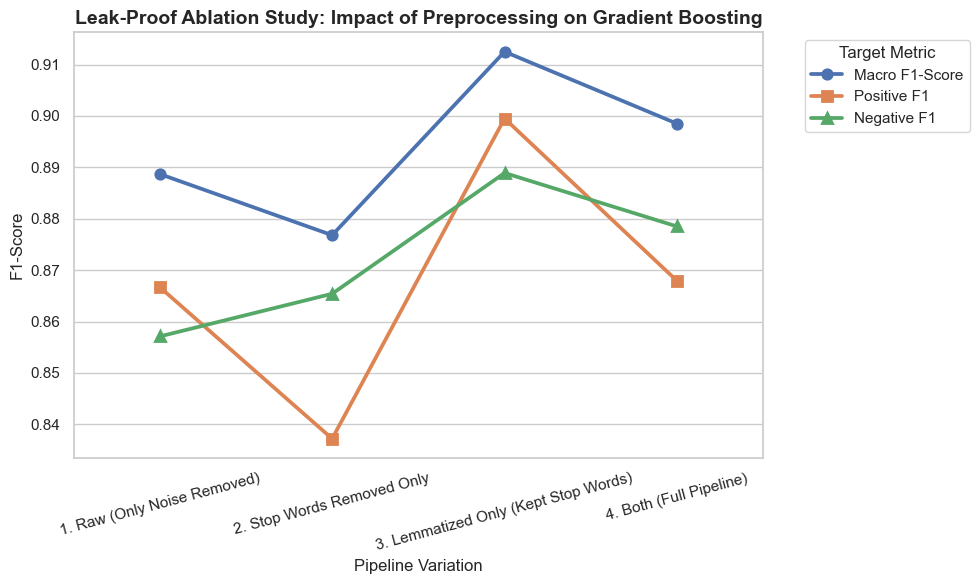

In [42]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

warnings.filterwarnings("ignore")

print("--- STEP 1: STRICT ISOLATION (SPLITTING FIRST) ---")

# 1. Split the entire DataFrame BEFORE any vectorization happens
df_train, df_test, y_train, y_test = train_test_split(
    df_nlp, df_nlp['sentiment'], test_size=0.2, random_state=42, stratify=df_nlp['sentiment']
)

# 2. Extract Meta Features for Train and Test separately
meta_features = ['word_count', 'has_currency', 'raw_digit_count', 
                 'ticker_acronym_count', 'hyphen_count'] 

X_meta_train = csr_matrix(df_train[meta_features].values)
X_meta_test = csr_matrix(df_test[meta_features].values)

# ====================================================================
# STEP 2: THE LEAK-PROOF TOURNAMENT (GRADIENT BOOSTING)
# ====================================================================
print("\nStep 2: Running Leak-Proof Gradient Boosting Tournament...")
print("Warning: Sequential tree models take longer to train. Tracking time...")

text_variations = {
    "1. Raw (Only Noise Removed)": "normalized_text",
    "2. Stop Words Removed Only": "text_no_stopwords",
    "3. Lemmatized Only (Kept Stop Words)": "text_lemma_only",
    "4. Both (Full Pipeline)": "ml_ready_text"
}

results = []

for name, col in text_variations.items():
    # A. Initialize Vectorizer
    tfidf = TfidfVectorizer(min_df=5, ngram_range=(1, 2))
    
    # B. Fit on Train, ONLY Transform on Test (Zero Leakage)
    X_text_train = tfidf.fit_transform(df_train[col])
    X_text_test = tfidf.transform(df_test[col])
    
    # C. Merge with pre-split Meta Features
    X_train_final = hstack([X_text_train, X_meta_train])
    X_test_final = hstack([X_text_test, X_meta_test])
    
    print(f"\n{name} -> Training Dimensions: {X_train_final.shape[1]:,}")
    
    # D. Train Gradient Boosting
    gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
    
    start_time = time.time()
    gb_model.fit(X_train_final, y_train)
    run_time = time.time() - start_time
    print(f"   Done in {run_time:.2f} seconds.")
    
    # E. Predict and Score
    y_pred = gb_model.predict(X_test_final)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Preprocessing Strategy": name,
        "Macro F1-Score": report['macro avg']['f1-score'],
        "Positive F1": report['positive']['f1-score'],
        "Negative F1": report['negative']['f1-score']
    })

# ====================================================================
# STEP 3: THE SCOREBOARD & VISUALIZATION
# ====================================================================
print("\n--- ABLATION STUDY SCOREBOARD (GRADIENT BOOSTING) ---")
results_df = pd.DataFrame(results).round(4)
display(results_df.sort_values(by="Macro F1-Score", ascending=False))

# Plot the climb in performance
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

df_melted = pd.melt(results_df, id_vars=['Preprocessing Strategy'], 
                    value_vars=['Macro F1-Score', 'Positive F1', 'Negative F1'],
                    var_name='Metric', value_name='Score')

sns.pointplot(data=df_melted, x='Preprocessing Strategy', y='Score', hue='Metric', markers=['o', 's', '^'])

plt.title("Leak-Proof Ablation Study: Impact of Preprocessing on Gradient Boosting", fontsize=14, fontweight='bold')
plt.ylabel("F1-Score", fontsize=12)
plt.xlabel("Pipeline Variation", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="Target Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### XgBoost :

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

warnings.filterwarnings("ignore")

print("--- STEP 1: STRICT ISOLATION (SPLITTING FIRST) ---")

# 1. Split the entire DataFrame BEFORE any vectorization happens
df_train, df_test, y_train, y_test = train_test_split(
    df_nlp, df_nlp['sentiment'], test_size=0.2, random_state=42, stratify=df_nlp['sentiment']
)

# 2. Extract Meta Features for Train and Test separately
meta_features = ['word_count', 'has_currency', 'raw_digit_count', 
                 'ticker_acronym_count', 'hyphen_count'] 

X_meta_train = csr_matrix(df_train[meta_features].values)
X_meta_test = csr_matrix(df_test[meta_features].values)

# 3. XGBoost Requirement: Label Encoding
# We must translate the string targets ('positive', 'negative', 'neutral') to integers (0, 1, 2)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
# Note: We keep y_test as strings because we will decode the predictions back to English later

# ====================================================================
# STEP 2: THE LEAK-PROOF TOURNAMENT (XGBOOST)
# ====================================================================
print("\nStep 2: Running Leak-Proof XGBoost Tournament...")
print("Utilizing XGBoost Sparsity-Aware Split Finding...")

text_variations = {
    "1. Raw (Only Noise Removed)": "normalized_text",
    "2. Stop Words Removed Only": "text_no_stopwords",
    "3. Lemmatized Only (Kept Stop Words)": "text_lemma_only",
    "4. Both (Full Pipeline)": "ml_ready_text"
}

results = []

for name, col in text_variations.items():
    # A. Initialize Vectorizer
    tfidf = TfidfVectorizer(min_df=5, ngram_range=(1, 2))
    
    # B. Fit on Train, ONLY Transform on Test (Zero Leakage)
    X_text_train = tfidf.fit_transform(df_train[col])
    X_text_test = tfidf.transform(df_test[col])
    
    # C. Merge with pre-split Meta Features
    X_train_final = hstack([X_text_train, X_meta_train])
    X_test_final = hstack([X_text_test, X_meta_test])
    
    print(f"\n{name} -> Training Dimensions: {X_train_final.shape[1]:,}")
    
    # D. Train XGBoost (Using parameters optimized for sparse text)
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss' # Silences backend warnings
    )
    
    start_time = time.time()
    # Feed it the purely numeric target variable
    xgb_model.fit(X_train_final, y_train_encoded)
    run_time = time.time() - start_time
    print(f"   Done in {run_time:.2f} seconds.")
    
    # E. Predict and Score
    # Predict returns numbers (0, 1, 2), we invert them back to English strings
    y_pred_numeric = xgb_model.predict(X_test_final)
    y_pred_strings = le.inverse_transform(y_pred_numeric)
    
    report = classification_report(y_test, y_pred_strings, output_dict=True)
    
    results.append({
        "Preprocessing Strategy": name,
        "Macro F1-Score": report['macro avg']['f1-score'],
        "Positive F1": report['positive']['f1-score'],
        "Negative F1": report['negative']['f1-score']
    })

# ====================================================================
# STEP 3: THE SCOREBOARD & VISUALIZATION
# ====================================================================
print("\n--- ABLATION STUDY SCOREBOARD (XGBOOST) ---")
results_df = pd.DataFrame(results).round(4)
display(results_df.sort_values(by="Macro F1-Score", ascending=False))

# Plot the climb in performance
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

df_melted = pd.melt(results_df, id_vars=['Preprocessing Strategy'], 
                    value_vars=['Macro F1-Score', 'Positive F1', 'Negative F1'],
                    var_name='Metric', value_name='Score')

sns.pointplot(data=df_melted, x='Preprocessing Strategy', y='Score', hue='Metric', markers=['o', 's', '^'])

plt.title("Leak-Proof Ablation Study: Impact of Preprocessing on XGBoost", fontsize=14, fontweight='bold')
plt.ylabel("F1-Score", fontsize=12)
plt.xlabel("Pipeline Variation", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="Target Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### HYPERPARAMETRIC TUNING :

#### LinearSVC 

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

print("--- GRIDSEARCHCV ON THE LINEAR SVC---")

# 1. STRICT ISOLATION: Split the raw dataframe FIRST
df_train, df_test, y_train, y_test = train_test_split(
    df_nlp, df_nlp['sentiment'], test_size=0.2, random_state=42, stratify=df_nlp['sentiment']
)

# 2. Vectorize the Champion Data (Learning from Train ONLY)
tfidf_final = TfidfVectorizer(min_df=5, ngram_range=(1, 2))

# CRITICAL FIX: Fit on Train, only Transform on Test
X_train_text = tfidf_final.fit_transform(df_train['text_lemma_only'])
X_test_text = tfidf_final.transform(df_test['text_lemma_only'])

# 3. Merge with Meta Features 
meta_features = ['word_count', 'has_currency', 'raw_digit_count', 'ticker_acronym_count', 'hyphen_count']
X_meta_train = csr_matrix(df_train[meta_features].values)
X_meta_test = csr_matrix(df_test[meta_features].values)

X_train_c = hstack([X_train_text, X_meta_train])
X_test_c = hstack([X_test_text, X_meta_test])

# Verify we have the correct, un-leaked dimensions (should be ~978)
print(f"Training Dimensions: {X_train_c.shape[1]:,} features\n")

# 4. Define the Parameter Grid for the SVM
param_grid = {
    'C': [0.01, 0.1, 1.0, 10, 100],            # Margin strictness
    'class_weight': ['balanced', None],        # Imbalance handling
    'loss': ['hinge', 'squared_hinge']         # Penalty calculation
}

base_svc = LinearSVC(random_state=42, dual="auto", max_iter=25000)

# 5. Launch the Grid Search Tournament
print("Testing 20 hyperparameter combinations (5-Fold CV)...")
grid_search = GridSearchCV(
    estimator=base_svc,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro', # Crucial: Optimize for the minority classes
    n_jobs=1, 
    verbose=1
)

grid_search.fit(X_train_c, y_train)

# 6. The Grand Finale
print("\n OPTIMAL HYPERPARAMETERS FOUND ")
print(grid_search.best_params_)

print("\n--- FINAL TUNED CHAMPION CLASSIFICATION REPORT ---")
y_pred_champ = grid_search.best_estimator_.predict(X_test_c)
print(classification_report(y_test, y_pred_champ))

#### Random Forest :

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from scipy.sparse import hstack, csr_matrix

print("--- FINAL PHASE: LEAK-PROOF GRIDSEARCHCV ON RANDOM FOREST ---")

# 1. STRICT ISOLATION: Split the raw dataframe FIRST
df_train, df_test, y_train, y_test = train_test_split(
    df_nlp, df_nlp['sentiment'], test_size=0.2, random_state=42, stratify=df_nlp['sentiment']
)

# 2. Vectorize the Champion Data for RF (Variation 4: Full Pipeline)
print("Vectorizing the fully-cleaned text (Strict Isolation)...")
tfidf_rf_final = TfidfVectorizer(min_df=5, ngram_range=(1, 2))

# CRITICAL FIX: Fit on Train, only Transform on Test
X_train_text_rf = tfidf_rf_final.fit_transform(df_train['ml_ready_text'])
X_test_text_rf = tfidf_rf_final.transform(df_test['ml_ready_text'])

# 3. Merge with Meta Features
meta_features = ['word_count', 'has_currency', 'raw_digit_count', 'ticker_acronym_count', 'hyphen_count']
X_meta_train = csr_matrix(df_train[meta_features].values)
X_meta_test = csr_matrix(df_test[meta_features].values)

X_train_rf = hstack([X_train_text_rf, X_meta_train])
X_test_rf = hstack([X_test_text_rf, X_meta_test])

print(f"Training Dimensions for RF: {X_train_rf.shape[1]:,} features\n")

# 4. Define the Parameter Grid
param_grid_rf = {
    'max_depth': [None, 50, 100, 150],         
    'min_samples_split': [5, 10],         
    'n_estimators': [100, 120, 150, 200]            
}

base_rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# 5. Launch the Grid Search 
print("Testing 32 hyperparameter combinations (Sequential CV to prevent OOM)...")
grid_search_rf = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1_macro', 
    n_jobs=1,  
    verbose=1
)

grid_search_rf.fit(X_train_rf, y_train) 

# 6. Evaluate and Print
print("\n OPTIMAL RANDOM FOREST HYPERPARAMETERS ")
print(grid_search_rf.best_params_)

print("\n--- FINAL TUNED RANDOM FOREST CLASSIFICATION REPORT ---")
y_pred_rf_champ = grid_search_rf.best_estimator_.predict(X_test_rf)
print(classification_report(y_test, y_pred_rf_champ))

#### Gradient Boosting :

In [43]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import classification_report
import time

print("--- GRIDSEARCHCV ON GRADIENT BOOSTING (LEMMA ONLY) ---")

# 1. STRICT ISOLATION: Split the raw dataframe FIRST
df_train, df_test, y_train, y_test = train_test_split(
    df_nlp, df_nlp['sentiment'], test_size=0.2, random_state=42, stratify=df_nlp['sentiment']
)

# 2. Vectorize the Lemmatized Data (Learning from Train ONLY)
tfidf_final = TfidfVectorizer(min_df=5, ngram_range=(1, 2))

# CRITICAL FIX: Fit on Train, only Transform on Test
X_train_text = tfidf_final.fit_transform(df_train['text_lemma_only'])
X_test_text = tfidf_final.transform(df_test['text_lemma_only'])

# 3. Merge with Meta Features 
meta_features = ['word_count', 'has_currency', 'raw_digit_count', 'ticker_acronym_count', 'hyphen_count']
X_meta_train = csr_matrix(df_train[meta_features].values)
X_meta_test = csr_matrix(df_test[meta_features].values)

X_train_c = hstack([X_train_text, X_meta_train])
X_test_c = hstack([X_test_text, X_meta_test])

print(f"Training Dimensions: {X_train_c.shape[1]:,} features\n")

# 4. Define the Parameter Grid for Gradient Boosting
# We use a focused, narrow grid to prevent agonizingly slow training times
param_grid = {
    'n_estimators': [100, 200],              # Number of sequential trees
    'learning_rate': [0.05, 0.1],            # Step size for learning
    'max_depth': [3, 5],                     # Tree complexity (keep shallow!)
    'min_samples_leaf': [1, 3]               # Regularization to prevent noise memorization
}

base_gb = GradientBoostingClassifier(random_state=42)

# 5. Launch the Grid Search Tournament
print("Testing 16 hyperparameter combinations (5-Fold CV)...")
print("This may take 3 to 5 minutes depending on your CPU. Please wait...")

start_time = time.time()

grid_search = GridSearchCV(
    estimator=base_gb,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro', # Crucial: Optimize for the minority classes
    n_jobs=1,          # Use ALL CPU cores to speed this up!
    verbose=1          # Gives you a progress bar in the console
)

grid_search.fit(X_train_c, y_train)
tuning_time = time.time() - start_time

# 6. The Grand Finale
print(f"\n GridSearch Completed in {tuning_time/60:.2f} minutes.")
print("\n OPTIMAL HYPERPARAMETERS FOUND ")
print(grid_search.best_params_)

print("\n--- FINAL TUNED CHAMPION CLASSIFICATION REPORT ---")
y_pred_champ = grid_search.best_estimator_.predict(X_test_c)
print(classification_report(y_test, y_pred_champ))

--- GRIDSEARCHCV ON GRADIENT BOOSTING (LEMMA ONLY) ---
Training Dimensions: 1,571 features

Testing 16 hyperparameter combinations (5-Fold CV)...
This may take 3 to 5 minutes depending on your CPU. Please wait...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

 GridSearch Completed in 3.54 minutes.

 OPTIMAL HYPERPARAMETERS FOUND 
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 100}

--- FINAL TUNED CHAMPION CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    negative       0.96      0.81      0.88        59
     neutral       0.90      0.99      0.94       274
    positive       0.95      0.81      0.87       111

    accuracy                           0.92       444
   macro avg       0.94      0.87      0.90       444
weighted avg       0.92      0.92      0.92       444



#### XGBoost :

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import classification_report
import time
import warnings

warnings.filterwarnings("ignore")

print("--- GRIDSEARCHCV ON XGBOOST (COMPLETE PIPELINE) ---")

# ====================================================================
# STEP 1: STRICT ISOLATION & PREPROCESSING
# ====================================================================
# 1. Split the raw dataframe FIRST
df_train, df_test, y_train, y_test = train_test_split(
    df_nlp, df_nlp['sentiment'], test_size=0.2, random_state=42, stratify=df_nlp['sentiment']
)

# 2. Vectorize the "Complete Pipeline" Data (Variation 4)
tfidf_final = TfidfVectorizer(min_df=5, ngram_range=(1, 2))

# CRITICAL FIX: Fit on Train, only Transform on Test
X_train_text = tfidf_final.fit_transform(df_train['ml_ready_text'])
X_test_text = tfidf_final.transform(df_test['ml_ready_text'])

# 3. Merge with Meta Features 
meta_features = ['word_count', 'has_currency', 'raw_digit_count', 'ticker_acronym_count', 'hyphen_count']
X_meta_train = csr_matrix(df_train[meta_features].values)
X_meta_test = csr_matrix(df_test[meta_features].values)

X_train_final = hstack([X_train_text, X_meta_train])
X_test_final = hstack([X_test_text, X_meta_test])

print(f"Training Dimensions: {X_train_final.shape[1]:,} features")

# 4. XGBoost Label Encoding (Target Variable)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# ====================================================================
# STEP 2: THE GRID SEARCH TOURNAMENT
# ====================================================================
# Define the smart parameter grid
param_grid = {
    'n_estimators': [100, 200],       # Number of trees
    'learning_rate': [0.05, 0.1],     # Shrinkage
    'max_depth': [3, 5],              # Shallow trees prevent overfitting
    'subsample': [0.8, 1.0]           # Row sampling for regularization
}

base_xgb = xgb.XGBClassifier(
    random_state=42, 
    n_jobs=-1, 
    eval_metric='mlogloss' # Keeps the console clean
)

print("\nTesting 16 hyperparameter combinations (5-Fold CV)...")
print("XGBoost is highly optimized, but this may still take 2-4 minutes. Please wait...")

start_time = time.time()

grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro', # Crucial: Optimize for the minority 'Negative' class
    n_jobs=1,        
    verbose=1           
)

grid_search.fit(X_train_final, y_train_encoded)
tuning_time = time.time() - start_time

# ====================================================================
# STEP 3: THE GRAND FINALE EVALUATION
# ====================================================================
print(f"\nGridSearch Completed in {tuning_time/60:.2f} minutes.")
print("\n OPTIMAL HYPERPARAMETERS FOUND ")
print(grid_search.best_params_)

# 1. Predict using the absolute best version of the model
y_pred_encoded = grid_search.best_estimator_.predict(X_test_final)

# 2. Translate the numeric predictions back to English strings
y_pred_final = le.inverse_transform(y_pred_encoded)

print("\n--- FINAL TUNED XGBOOST CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_final))

### Overall Comparison :

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

print("--- THE ULTIMATE FINAL MODEL COMPARISON TABLE ---")

# 1. Generate the classification reports as dictionaries
# Ensure all models evaluate against the exact same, mathematically pure y_test
report_svc = classification_report(y_test, y_pred_svc, output_dict=True)
report_rf  = classification_report(y_test, y_pred_rf, output_dict=True)
report_gb  = classification_report(y_test, y_pred_gb, output_dict=True) 
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True) 

# 2. Extract the critical metrics into a structured list of dictionaries
comparison_data = [
    {
        "Model": "Tuned LinearSVC",
        "Macro Precision": report_svc['macro avg']['precision'],
        "Macro Recall": report_svc['macro avg']['recall'],
        "Macro F1-Score": report_svc['macro avg']['f1-score'],
        "Negative F1": report_svc['negative']['f1-score'],
        "Positive F1": report_svc['positive']['f1-score']
    },
    {
        "Model": "Tuned Random Forest",
        "Macro Precision": report_rf['macro avg']['precision'],
        "Macro Recall": report_rf['macro avg']['recall'],
        "Macro F1-Score": report_rf['macro avg']['f1-score'],
        "Negative F1": report_rf['negative']['f1-score'],
        "Positive F1": report_rf['positive']['f1-score']
    },
    {
        "Model": "Tuned Gradient Boosting",
        "Macro Precision": report_gb['macro avg']['precision'],
        "Macro Recall": report_gb['macro avg']['recall'],
        "Macro F1-Score": report_gb['macro avg']['f1-score'],
        "Negative F1": report_gb['negative']['f1-score'],
        "Positive F1": report_gb['positive']['f1-score']
    },
    {
        "Model": "Tuned XGBoost",
        "Macro Precision": report_xgb['macro avg']['precision'],
        "Macro Recall": report_xgb['macro avg']['recall'],
        "Macro F1-Score": report_xgb['macro avg']['f1-score'],
        "Negative F1": report_xgb['negative']['f1-score'],
        "Positive F1": report_xgb['positive']['f1-score']
    }
]

# 3. Convert to a Pandas DataFrame
df_comparison = pd.DataFrame(comparison_data)

# 4. Sort by Macro F1-Score to show the hierarchy, then set 'Model' as index
df_comparison = df_comparison.sort_values(by="Macro F1-Score", ascending=False).set_index("Model")

# 5. Display the rounded table
display(df_comparison.round(3))

In [48]:
import pickle

# 1. Save your TF-IDF Vectorizer
# (If your vectorizer is named something else like 'vectorizer', change 'tfidf' to match)
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_final, f)

# 2. Save your Gradient Boosting Model
# (If your model is named 'gb_model' or 'gb', change 'gb_baseline' to match)
with open("gb_model.pkl", "wb") as f:
    pickle.dump(base_gb, f)

print("SUCCESS! gb_model.pkl and tfidf_vectorizer.pkl have been extracted.")

SUCCESS! gb_model.pkl and tfidf_vectorizer.pkl have been extracted.


# DEEP LEARNING MODELS #


## ANN/MLP :

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize and encode your classical split variables
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report
import numpy as np

print("--- PHASE 1: TENSORFLOW DATA WRAPPING (FINAL COMBINED MATRICES) ---")

# 1. Convert your final merged SciPy sparse matrices to dense NumPy arrays for TensorFlow
X_train_ann = X_train_final.toarray()
X_test_ann = X_test_final.toarray()

# Mapping your encoded target labels (from the earlier LabelEncoder phase)
y_train_ann = np.array(y_train_encoded)
y_test_ann = np.array(y_test_encoded)

INPUT_DIM = X_train_ann.shape[1]
NUM_CLASSES = 3
BATCH_SIZE_ANN = 32

print(f"ANN Input Dimension (TF-IDF Words + Meta Features): {INPUT_DIM:,}")

# ====================================================================
# PHASE 2 & 3: SEQUENTIAL MODEL CONFIGURATION
# ====================================================================
print("\n--- PHASE 2 & 3: CONFIGURING TENSORFLOW SEQUENTIAL GRAPH ---")

model_ann = models.Sequential([
    # Input Specification Layer mapping the full combined width
    layers.Input(shape=(INPUT_DIM,)),
    
    # Hidden Layer 1: 256 Neurons + L2 Weight Decay to stabilize sparse + dense inputs
    layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5), # Regularization to prevent half a million parameters from overfitting
    
    # Hidden Layer 2: 128 Neurons bottleneck
    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    
    # Output Head: 3 un-normalized logit scores
    layers.Dense(NUM_CLASSES, activation=None)
])

# Display the structural parameters
model_ann.summary()

# ====================================================================
# PHASE 4: COMPILATION & MODEL TRAINING
# ====================================================================
print("\n--- PHASE 4: COMPILING AND TRAINING ENGINE ---")

model_ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Set up the automated callback to capture the absolute peak generalization weights
checkpoint_cb = ModelCheckpoint(
    filepath='best_tf_ann_final_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Execute the training pipeline
history = model_ann.fit(
    X_train_ann, y_train_ann,
    validation_data=(X_test_ann, y_test_ann),
    epochs=20,
    batch_size=BATCH_SIZE_ANN,
    callbacks=[checkpoint_cb],
    verbose=1
)

# ====================================================================
# PHASE 5: EVALUATION REPORT GENERATION
# ====================================================================
print("\n--- PHASE 5: POST-TRAINING INFERENCE ---")

# Reload the optimal weights that achieved the absolute lowest validation loss
print("Loading champion checkpoint graph...")
best_model = models.load_model('best_tf_ann_final_model.keras')

# Predict raw logits on your hidden final test matrix
raw_logits = best_model.predict(X_test_ann)

# Find the highest scoring index for each row
y_pred_ann = np.argmax(raw_logits, axis=1)
target_names = label_encoder.classes_

print("\n FINAL TENSORFLOW ANN CLASSIFICATION REPORT ")
print(classification_report(y_test_ann, y_pred_ann, target_names=target_names, digits=4))

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report
import numpy as np

print("--- PHASE 1: TENSORFLOW DATA WRAPPING (PURE TEXT ONLY) ---")

# 1. Convert ONLY the TF-IDF text matrices to dense NumPy arrays
# We are intentionally ignoring X_meta_train and the merged X_train_final
X_train_ann_text = X_text_train_tfidf.toarray()
X_test_ann_text = X_text_test_tfidf.toarray()

y_train_ann = np.array(y_train_encoded)
y_test_ann = np.array(y_test_encoded)

INPUT_DIM_TEXT = X_train_ann_text.shape[1]
NUM_CLASSES = 3
BATCH_SIZE_ANN = 32

print(f"ANN Input Dimension (TF-IDF Words ONLY): {INPUT_DIM_TEXT:,}")

# ====================================================================
# PHASE 2 & 3: SEQUENTIAL MODEL CONFIGURATION
# ====================================================================
print("\n--- PHASE 2 & 3: CONFIGURING TEXT-ONLY SEQUENTIAL GRAPH ---")

model_ann_text = models.Sequential([
    # Input Specification Layer mapping only the text vocabulary width
    layers.Input(shape=(INPUT_DIM_TEXT,)),
    
    # Hidden Layer 1: 256 Neurons + L2 Weight Decay
    layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5), 
    
    # Hidden Layer 2: 128 Neurons bottleneck
    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    
    # Output Head: 3 un-normalized logit scores
    layers.Dense(3, activation=None)
])

# Display the structural parameters
model_ann_text.summary()

# ====================================================================
# PHASE 4: COMPILATION & MODEL TRAINING
# ====================================================================
print("\n--- PHASE 4: COMPILING AND TRAINING ENGINE ---")

model_ann_text.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Automated callback to capture the peak generalization weights for the text-only model
checkpoint_cb_text = ModelCheckpoint(
    filepath='best_tf_ann_text_only.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Execute the training pipeline
history_text = model_ann_text.fit(
    X_train_ann_text, y_train_ann,
    validation_data=(X_test_ann_text, y_test_ann),
    epochs=20,
    batch_size=BATCH_SIZE_ANN,
    callbacks=[checkpoint_cb_text],
    verbose=1
)

# ====================================================================
# PHASE 5: EVALUATION REPORT GENERATION
# ====================================================================
print("\n--- PHASE 5: POST-TRAINING INFERENCE ---")

# Reload the optimal weights for the text-only model
print("Loading text-only champion checkpoint graph...")
best_model_text = models.load_model('best_tf_ann_text_only.keras')

# Predict raw logits on the hidden test matrix
raw_logits_text = best_model_text.predict(X_test_ann_text)

# Find the highest scoring index for each row
y_pred_ann_text = np.argmax(raw_logits_text, axis=1)

# Resolve target strings
try:
    target_names = label_encoder.classes_
except NameError:
    target_names = ['negative', 'neutral', 'positive']

print("\n TEXT-ONLY TENSORFLOW ANN CLASSIFICATION REPORT ")
print(classification_report(y_test_ann, y_pred_ann_text, target_names=target_names, digits=4))

## ROUGH :

### DATA PREPROCESSING :

#### WORD2VEC :

In [ ]:
#Word2vec and Doc2vec are two popular techniques in natural language processing (NLP) for representing words and documents as vectors in a continuous vector space. These techniques are based on the idea that words that appear in similar contexts tend to have similar meanings.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec

print("--- CUSTOM WORD2VEC & PYTORCH TENSOR PIPELINE ---")

# 1. STRICT ISOLATION
df_train, df_test = train_test_split(df_nlp, test_size=0.2, random_state=42, stratify=df_nlp['sentiment'])

# 2. Tokenize the Training Data for Gensim
# Gensim requires a list of tokenized lists: [['the', 'revenue', 'grew'], ['costs', 'dropped']]
train_sentences = [str(text).split() for text in df_train['text_lemma_only']]

# ====================================================================
# STEP A: TRAIN THE CUSTOM VECTOR SPACE
# ====================================================================
print("Training Custom Word2Vec Space on Training Data...")
EMBEDDING_DIM = 100 # Reduced from 300 because our dataset is small

custom_w2v = Word2Vec(
    sentences=train_sentences,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=5,        # The equivalent of min_df=2
    workers=8,          # Parallel CPU threads
    sg=1,               # Skip-Gram architecture (better for rare financial words)
    epochs=20           # Higher epochs needed for small datasets
)

learned_vocab_size = len(custom_w2v.wv)
print(f"Custom Word2Vec converged. Learned distinct vectors for {learned_vocab_size:,} words.")

# ====================================================================
# STEP B: CONSTRUCT THE NEURAL VOCABULARY MAPPING
# ====================================================================
print("\nConstructing PyTorch Vocabulary and Embedding Matrix...")

# We must reserve index 0 for <PAD> and index 1 for <UNK> (Out of Vocabulary)
word2idx = {"<PAD>": 0, "<UNK>": 1}
current_idx = 2

# Initialize the embedding matrix with zeros
# Size = Learned words + 2 (for PAD and UNK)
TOTAL_VOCAB_SIZE = learned_vocab_size + 2
embedding_matrix = np.zeros((TOTAL_VOCAB_SIZE, EMBEDDING_DIM))

# Generate a random distribution for the <UNK> token 
# (Standard practice so unseen test words don't zero-out the network)
embedding_matrix[1] = np.random.normal(scale=0.6, size=(EMBEDDING_DIM,))

# Extract the learned weights from Gensim into our PyTorch matrix
for word in custom_w2v.wv.index_to_key:
    word2idx[word] = current_idx
    embedding_matrix[current_idx] = custom_w2v.wv[word]
    current_idx += 1

# ====================================================================
# STEP C: INITIALIZE THE PYTORCH EMBEDDING LAYER
# ====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tensor_embeddings = torch.tensor(embedding_matrix, dtype=torch.float32)

# Initialize the layer
custom_embedding_layer = nn.Embedding.from_pretrained(
    embeddings=tensor_embeddings, 
    freeze=False, # We allow the network to fine-tune these custom weights
    padding_idx=word2idx["<PAD>"]
).to(device)

print(f" PyTorch Layer Initialized.")
print(f"Matrix Shape: {custom_embedding_layer.weight.shape} (Vocab Size x Vector Dim)")

#### FASTTEXT

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from gensim.models import FastText

print("--- PHASE 1: CUSTOM FASTTEXT & PYTORCH EMBEDDING PIPELINE ---")

# 1. STRICT ISOLATION & TOKENIZATION
# Using your lemma text which preserves structural punctuation
df_train_ft, df_test_ft = train_test_split(df_nlp, test_size=0.2, random_state=42, stratify=df_nlp['sentiment'])

# Gensim requires an iterable of tokenized lists
train_sentences_ft = [str(text).split() for text in df_train_ft['text_lemma_only']]

# ====================================================================
# STEP A: TRAIN THE SUBWORD VECTOR SPACE
# ====================================================================
print("\nTraining Custom FastText Space on Training Data...")
EMBEDDING_DIM_FT = 100 

custom_ft_model = FastText(
    sentences=train_sentences_ft,
    vector_size=EMBEDDING_DIM_FT,
    window=5,           # Context window size
    min_count=5,        # Discard rare tokens (equivalent to min_df)
    workers=4,          # Parallel CPU threads
    sg=1,               # Skip-Gram architecture
    epochs=25,          # High epoch count required for small datasets
    min_n=3,            # Minimum subword length (e.g., 'rev')
    max_n=6             # Maximum subword length (e.g., 'revenu')
)

learned_vocab_size_ft = len(custom_ft_model.wv)
print(f"FastText converged. Learned vectors for {learned_vocab_size_ft:,} distinct words.")

# ====================================================================
# STEP B: CONSTRUCT THE NEURAL VOCABULARY MAPPING
# ====================================================================
print("Constructing PyTorch Vocabulary and Embedding Matrix...")

# Reserve index 0 for <PAD> and index 1 for <UNK>
word2idx_ft = {"<PAD>": 0, "<UNK>": 1}
current_idx_ft = 2

# Initialize the zero matrix: Shape (Vocab Size + 2, Embedding Dim)
TOTAL_VOCAB_SIZE_FT = learned_vocab_size_ft + 2
embedding_matrix_ft = np.zeros((TOTAL_VOCAB_SIZE_FT, EMBEDDING_DIM_FT))

# Initialize <UNK> with a standard normal distribution
embedding_matrix_ft[1] = np.random.normal(scale=0.6, size=(EMBEDDING_DIM_FT,))

# Map the learned FastText weights into the PyTorch matrix
for word in custom_ft_model.wv.index_to_key:
    word2idx_ft[word] = current_idx_ft
    embedding_matrix_ft[current_idx_ft] = custom_ft_model.wv[word]
    current_idx_ft += 1

# ====================================================================
# STEP C: INITIALIZE THE PYTORCH EMBEDDING LAYER
# ====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tensor_embeddings_ft = torch.tensor(embedding_matrix_ft, dtype=torch.float32)

embedding_layer_ft = nn.Embedding.from_pretrained(
    embeddings=tensor_embeddings_ft, 
    freeze=False, # We allow the BiLSTM backpropagation to fine-tune these weights
    padding_idx=word2idx_ft["<PAD>"]
).to(device)

print(f"\nPyTorch Layer Initialized on {device}.")
print(f"Matrix Shape: {embedding_layer_ft.weight.shape} (Vocab Size x Vector Dim)")

# ====================================================================
# STEP D: OOV CAPABILITY VERIFICATION
# ====================================================================
test_word = "overleveraged" # Highly likely to be absent from training
print(f"\nVerifying OOV handling for test token: '{test_word}'")
try:
    # We query the Gensim model directly to prove it infers the vector
    vector = custom_ft_model.wv[test_word]
    print("SUCCESS: FastText dynamically generated a vector using subword n-grams.")
except KeyError as e:
    print(f"CRITICAL FAILURE: {e}")

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

print("--- PIPELINE A: WORD2VEC SEQUENCE PADDING & DATALOADER ---")

# 1. Namespace-Isolated Target Encoding
le_w2v = LabelEncoder()
y_train_w2v = le_w2v.fit_transform(df_train['sentiment'])
y_test_w2v = le_w2v.transform(df_test['sentiment'])

MAX_LEN_W2V = 40

# 2. Dedicated Word2Vec Dataset Class
class Word2VecSequenceDataset(Dataset):
    def __init__(self, texts, labels, word_mapping, max_length):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels
        self.word_mapping = word_mapping
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        sentence = str(self.texts.iloc[idx]).split()
        
        # Mapping lookup: Default to 1 (<UNK>) if word is missing from custom W2V vocab
        sequence = [self.word_mapping.get(word, 1) for word in sentence]
        
        # Truncation
        if len(sequence) > self.max_length:
            sequence = sequence[:self.max_length]
        # Padding
        else:
            padding_length = self.max_length - len(sequence)
            sequence = sequence + [0] * padding_length
            
        return (
            torch.tensor(sequence, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

# 3. Instantiate Isolated Dataset Objects
train_dataset_w2v = Word2VecSequenceDataset(
    texts=df_train['text_lemma_only'],
    labels=y_train_w2v,
    word_mapping=word2idx, # Utilizing Word2Vec vocabulary mapping dictionary
    max_length=MAX_LEN_W2V
)

test_dataset_w2v = Word2VecSequenceDataset(
    texts=df_test['text_lemma_only'],
    labels=y_test_w2v,
    word_mapping=word2idx,
    max_length=MAX_LEN_W2V
)

# 4. Construct DataLoaders
BATCH_SIZE_W2V = 32
train_loader_w2v = DataLoader(train_dataset_w2v, batch_size=BATCH_SIZE_W2V, shuffle=True, drop_last=True)
test_loader_w2v = DataLoader(test_dataset_w2v, batch_size=BATCH_SIZE_W2V, shuffle=False)

# 5. Pipeline Dimension Verification
sample_x_w2v, sample_y_w2v = next(iter(train_loader_w2v))
print("\nWord2Vec Data Pipeline Active.")
print(f"Batch X Shape: {sample_x_w2v.shape} -> (Batch Size, Sequence Length)")
print(f"Batch Y Shape: {sample_y_w2v.shape} -> (Batch Size)")

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

print("--- PIPELINE B: FASTTEXT SEQUENCE PADDING & DATALOADER ---")

# 1. Namespace-Isolated Target Encoding
le_ft = LabelEncoder()
y_train_ft = le_ft.fit_transform(df_train_ft['sentiment'])
y_test_ft = le_ft.transform(df_test_ft['sentiment'])

MAX_LEN_FT = 40

# 2. Dedicated FastText Dataset Class
class FastTextSequenceDataset(Dataset):
    def __init__(self, texts, labels, word_mapping, max_length):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels
        self.word_mapping = word_mapping
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        sentence = str(self.texts.iloc[idx]).split()
        
        # Mapping lookup: Default to 1 (<UNK>) if whole-word token is missing from train vocab
        sequence = [self.word_mapping.get(word, 1) for word in sentence]
        
        # Truncation
        if len(sequence) > self.max_length:
            sequence = sequence[:self.max_length]
        # Padding
        else:
            padding_length = self.max_length - len(sequence)
            sequence = sequence + [0] * padding_length
            
        return (
            torch.tensor(sequence, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

# 3. Instantiate Isolated Dataset Objects
train_dataset_ft = FastTextSequenceDataset(
    texts=df_train_ft['text_lemma_only'],
    labels=y_train_ft,
    word_mapping=word2idx_ft, # Utilizing isolated FastText vocabulary mapping dictionary
    max_length=MAX_LEN_FT
)

test_dataset_ft = FastTextSequenceDataset(
    texts=df_test_ft['text_lemma_only'],
    labels=y_test_ft,
    word_mapping=word2idx_ft,
    max_length=MAX_LEN_FT
)

# 4. Construct DataLoaders
BATCH_SIZE_FT = 32
train_loader_ft = DataLoader(train_dataset_ft, batch_size=BATCH_SIZE_FT, shuffle=True, drop_last=True)
test_loader_ft = DataLoader(test_dataset_ft, batch_size=BATCH_SIZE_FT, shuffle=False)

# 5. Pipeline Dimension Verification
sample_x_ft, sample_y_ft = next(iter(train_loader_ft))
print("\n FastText Data Pipeline Active.")
print(f"Batch X Shape: {sample_x_ft.shape} -> (Batch Size, Sequence Length)")
print(f"Batch Y Shape: {sample_y_ft.shape} -> (Batch Size)")

### Phase 3: Architecting the Sequence Memory (BiLSTM)

In [ ]:
import torch
import torch.nn as nn

print("--- PIPELINE A: WORD2VEC BiLSTM ARCHITECTURE ---")

class FinancialBiLSTM_W2V(nn.Module):
    def __init__(self, embedding_layer, hidden_size, num_layers, num_classes, dropout_rate):
        super(FinancialBiLSTM_W2V, self).__init__()
        
        # 1. The Word2Vec Embedding Layer (Passed from Phase 1)
        self.embedding = embedding_layer
        
        # Extract the embedding dimension dynamically to prevent hardcoding errors
        embedding_dim = self.embedding.weight.shape[1] 
        
        # 2. The Recurrent BiLSTM Layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,      # Forces input/output tensors to be (Batch, Seq, Feature)
            bidirectional=True,    # 2 independent LSTMs (Forward & Backward)
            dropout=dropout_rate if num_layers > 1 else 0 # Prevents overfitting between stacked layers
        )
        
        # 3. Regularization & Output Head
        self.dropout = nn.Dropout(dropout_rate)
        
        # hidden_size * 2 because we concatenate the forward and backward final states
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        
    def forward(self, x):
        # x shape: (batch_size, seq_length) -> e.g., (32, 40)
        
        # Pass through Word2Vec Space
        embedded = self.embedding(x) 
        # embedded shape: (batch_size, seq_length, embedding_dim) -> (32, 40, 100)
        
        # Pass through BiLSTM
        # lstm_out contains all time steps. hidden_state contains the final states.
        lstm_out, (hidden_state, cell_state) = self.lstm(embedded)
        
        # Extract the final forward (index -2) and backward (index -1) hidden states
        # Shape of hidden_state: (num_layers * 2, batch_size, hidden_size)
        hidden_forward = hidden_state[-2, :, :]
        hidden_backward = hidden_state[-1, :, :]
        
        # Concatenate them to form a unified bidirectional context vector
        # Shape: (batch_size, hidden_size * 2)
        combined_context = torch.cat((hidden_forward, hidden_backward), dim=1)
        
        # Apply dropout to prevent co-adaptation of neurons
        dropped = self.dropout(combined_context)
        
        # Calculate raw un-normalized scores (logits) for the 3 classes
        # Shape: (batch_size, 3)
        logits = self.fc(dropped)
        
        return logits

# Initialize Model A
print("Instantiating Word2Vec Graph...")
w2v_model = FinancialBiLSTM_W2V(
    embedding_layer=custom_embedding_layer, # From Phase 1 W2V
    hidden_size=64, 
    num_layers=2, 
    num_classes=3, 
    dropout_rate=0.3
).to(device)

# Sanity Check (Forward Pass)
# Passing the sample batch from Phase 2 DataLoader
out_w2v = w2v_model(sample_x_w2v.to(device))
print(f"Word2Vec Model Output Shape: {out_w2v.shape} (Batch Size, Classes)")

In [ ]:
import torch
import torch.nn as nn

print("--- PIPELINE B: FASTTEXT BiLSTM ARCHITECTURE ---")

class FinancialBiLSTM_FT(nn.Module):
    def __init__(self, embedding_layer, hidden_size, num_layers, num_classes, dropout_rate):
        super(FinancialBiLSTM_FT, self).__init__()
        
        # 1. The FastText Embedding Layer (Passed from Phase 1)
        self.embedding = embedding_layer
        embedding_dim = self.embedding.weight.shape[1] 
        
        # 2. The Recurrent BiLSTM Layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout_rate if num_layers > 1 else 0
        )
        
        # 3. Regularization & Output Head
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        
    def forward(self, x):
        # Pass through FastText Subword Space
        embedded = self.embedding(x) 
        
        # Sequential Memory Processing
        lstm_out, (hidden_state, cell_state) = self.lstm(embedded)
        
        # Isolate final forward and backward sequence states
        hidden_forward = hidden_state[-2, :, :]
        hidden_backward = hidden_state[-1, :, :]
        
        # Combine contextual memory
        combined_context = torch.cat((hidden_forward, hidden_backward), dim=1)
        dropped = self.dropout(combined_context)
        
        # Generate Logits
        logits = self.fc(dropped)
        return logits

# Initialize Model B
print("Instantiating FastText Graph...")
ft_model = FinancialBiLSTM_FT(
    embedding_layer=embedding_layer_ft, # From Phase 1 FastText
    hidden_size=64, 
    num_layers=2, 
    num_classes=3, 
    dropout_rate=0.3
).to(device)

# Sanity Check (Forward Pass)
# Passing the sample batch from Phase 2 DataLoader
out_ft = ft_model(sample_x_ft.to(device))
print(f" FastText Model Output Shape: {out_ft.shape} (Batch Size, Classes)")

### Phase 4: The Training Loop (Backpropagation & Gradient Descent)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

print("--- PIPELINE A: WORD2VEC BiLSTM TRAINING LOOP ---")

# 1. Architecture Optimization Setup
criterion_w2v = nn.CrossEntropyLoss()
optimizer_w2v = optim.Adam(w2v_model.parameters(), lr=0.001)

EPOCHS = 15
best_val_loss_w2v = float('inf')
best_model_weights_w2v = None
checkpoint_epoch_w2v = 0

print(f"Initiating Word2Vec Training Engine on {device}...")

for epoch in range(EPOCHS):
    
    # ====================================================================
    # STEP A: TRAINING PHASE
    # ====================================================================
    w2v_model.train() 
    train_loss = 0.0
    
    for batch_x, batch_y in train_loader_w2v:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer_w2v.zero_grad()
        outputs = w2v_model(batch_x)
        loss = criterion_w2v(outputs, batch_y)
        loss.backward()
        optimizer_w2v.step()
        
        train_loss += loss.item() * batch_x.size(0)
        
    epoch_train_loss = train_loss / len(train_loader_w2v.dataset)
    
    # ====================================================================
    # STEP B: VALIDATION PHASE
    # ====================================================================
    w2v_model.eval() 
    val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader_w2v:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = w2v_model(batch_x)
            loss = criterion_w2v(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            
            _, predicted_classes = torch.max(outputs, 1)
            total_predictions += batch_y.size(0)
            correct_predictions += (predicted_classes == batch_y).sum().item()
            
    epoch_val_loss = val_loss / len(test_loader_w2v.dataset)
    epoch_val_acc = correct_predictions / total_predictions
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | W2V Train Loss: {epoch_train_loss:.4f} | W2V Val Loss: {epoch_val_loss:.4f} | W2V Val Acc: {epoch_val_acc:.4f}")
    
    # ====================================================================
    # STEP C: CHECKPOINTING
    # ====================================================================
    if epoch_val_loss < best_val_loss_w2v:
        best_val_loss_w2v = epoch_val_loss
        best_model_weights_w2v = copy.deepcopy(w2v_model.state_dict())
        checkpoint_epoch_w2v = epoch + 1

print(f"\nWord2Vec Training Complete.")
print(f"Restoring optimal W2V weights from Epoch {checkpoint_epoch_w2v} (Val Loss: {best_val_loss_w2v:.4f}).")
w2v_model.load_state_dict(best_model_weights_w2v)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

print("--- PIPELINE B: FASTTEXT BiLSTM TRAINING LOOP ---")

# 1. Architecture Optimization Setup
criterion_ft = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(ft_model.parameters(), lr=0.001)

EPOCHS = 15
best_val_loss_ft = float('inf')
best_model_weights_ft = None
checkpoint_epoch_ft = 0

print(f"Initiating FastText Training Engine on {device}...")

for epoch in range(EPOCHS):
    
    # ====================================================================
    # STEP A: TRAINING PHASE
    # ====================================================================
    ft_model.train() 
    train_loss = 0.0
    
    for batch_x, batch_y in train_loader_ft:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer_ft.zero_grad()
        outputs = ft_model(batch_x)
        loss = criterion_ft(outputs, batch_y)
        loss.backward()
        optimizer_ft.step()
        
        train_loss += loss.item() * batch_x.size(0)
        
    epoch_train_loss = train_loss / len(train_loader_ft.dataset)
    
    # ====================================================================
    # STEP B: VALIDATION PHASE
    # ====================================================================
    ft_model.eval() 
    val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader_ft:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = ft_model(batch_x)
            loss = criterion_ft(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            
            _, predicted_classes = torch.max(outputs, 1)
            total_predictions += batch_y.size(0)
            correct_predictions += (predicted_classes == batch_y).sum().item()
            
    epoch_val_loss = val_loss / len(test_loader_ft.dataset)
    epoch_val_acc = correct_predictions / total_predictions
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | FT Train Loss: {epoch_train_loss:.4f} | FT Val Loss: {epoch_val_loss:.4f} | FT Val Acc: {epoch_val_acc:.4f}")
    
    # ====================================================================
    # STEP C: CHECKPOINTING
    # ====================================================================
    if epoch_val_loss < best_val_loss_ft:
        best_val_loss_ft = epoch_val_loss
        best_model_weights_ft = copy.deepcopy(ft_model.state_dict())
        checkpoint_epoch_ft = epoch + 1

print(f"\n FastText Training Complete.")
print(f"Restoring optimal FastText weights from Epoch {checkpoint_epoch_ft} (Val Loss: {best_val_loss_ft:.4f}).")
ft_model.load_state_dict(best_model_weights_ft)

### Phase 5: Evaluation, Inference, and Metric Generation

In [ ]:
import torch
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

print("--- PIPELINE A: WORD2VEC BiLSTM EVALUATION ---")

# 1. Set model to evaluation mode (Disables dropout regularisation)
w2v_model.eval()

y_true_w2v = []
y_pred_w2v = []

# 2. Iterate through test loader without calculating gradients
with torch.no_grad():
    for batch_x, batch_y in test_loader_w2v:
        # Move inputs to active device graph
        batch_x = batch_x.to(device)
        
        # Forward pass to obtain raw class logits
        logits = w2v_model(batch_x)
        
        # Apply argmax across dimension 1 to determine highest-scoring class indices
        _, predicted_classes = torch.max(logits, dim=1)
        
        # Append batch predictions and targets to main arrays
        y_pred_w2v.extend(predicted_classes.cpu().numpy())
        y_true_w2v.extend(batch_y.numpy())

# 3. Map integer indices back to original string classifications
resolved_classes_w2v = le_w2v.classes_

print("\n WORD2VEC CHAMPION CLASSIFICATION REPORT")
print(classification_report(
    y_true_w2v, 
    y_pred_w2v, 
    target_names=resolved_classes_w2v, 
    digits=4
))

# 4. Generate Raw Confusion Matrix for error distribution analysis
cm_w2v = confusion_matrix(y_true_w2v, y_pred_w2v)
df_cm_w2v = pd.DataFrame(cm_w2v, index=resolved_classes_w2v, columns=resolved_classes_w2v)
print("\n--- WORD2VEC CONFUSION MATRIX ---")
print(df_cm_w2v)

In [ ]:
import torch
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

print("--- PIPELINE B: FASTTEXT BiLSTM EVALUATION ---")

# 1. Set model to evaluation mode
ft_model.eval()

y_true_ft = []
y_pred_ft = []

# 2. Evaluation pass
with torch.no_grad():
    for batch_x, batch_y in test_loader_ft:
        batch_x = batch_x.to(device)
        
        logits = ft_model(batch_x)
        _, predicted_classes = torch.max(logits, dim=1)
        
        y_pred_ft.extend(predicted_classes.cpu().numpy())
        y_true_ft.extend(batch_y.numpy())

# 3. Map integer indices back to original string classifications
resolved_classes_ft = le_ft.classes_

print("\n FASTTEXT CHAMPION CLASSIFICATION REPORT ")
print(classification_report(
    y_true_ft, 
    y_pred_ft, 
    target_names=resolved_classes_ft, 
    digits=4
))

# 4. Generate Raw Confusion Matrix
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
df_cm_ft = pd.DataFrame(cm_ft, index=resolved_classes_ft, columns=resolved_classes_ft)
print("\n--- FASTTEXT CONFUSION MATRIX ---")
print(df_cm_ft)

### Pre trained fasttext model 

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import gensim.downloader as api
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("--- TRANSFER LEARNING: PRE-TRAINED FASTTEXT PIPELINE ---")

# 1. Hardware Definition & Strict Isolation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df_train_pt, df_test_pt = train_test_split(df_nlp, test_size=0.2, random_state=42, stratify=df_nlp['sentiment'])

# ====================================================================
# PHASE 1: VOCABULARY AND EMBEDDING MATRIX CONSTRUCTION
# ====================================================================
print("\n[1/3] Downloading/Loading 16B Token FastText Vectors (300d)...")
# Note: If already downloaded previously, Gensim will load it instantly from cache
pt_fasttext = api.load('fasttext-wiki-news-subwords-300')
EMBEDDING_DIM_PT = 300

print("[2/3] Constructing Financial Vocabulary Mapping...")
word2idx_pt = {"<PAD>": 0, "<UNK>": 1}
current_idx_pt = 2

# We map ONLY the words present in our training set to prevent memory overflow
for sentence in df_train_pt['text_lemma_only']:
    for token in str(sentence).split():
        if token not in word2idx_pt:
            word2idx_pt[token] = current_idx_pt
            current_idx_pt += 1

TOTAL_VOCAB_SIZE_PT = len(word2idx_pt)
embedding_matrix_pt = np.zeros((TOTAL_VOCAB_SIZE_PT, EMBEDDING_DIM_PT))
embedding_matrix_pt[1] = np.random.normal(scale=0.6, size=(EMBEDDING_DIM_PT,)) # <UNK> init

print(f"Vocabulary Size: {TOTAL_VOCAB_SIZE_PT:,} unique tokens.")
print("Extracting dense representations from pre-trained model...")

# Populate PyTorch matrix utilizing Gensim's subword inference for any missing financial jargon
for word, idx in word2idx_pt.items():
    if word in ["<PAD>", "<UNK>"]: continue
    try:
        embedding_matrix_pt[idx] = pt_fasttext[word]
    except KeyError:
        # Fallback if a token completely lacks valid character n-grams (extremely rare in FastText)
        embedding_matrix_pt[idx] = np.random.normal(scale=0.6, size=(EMBEDDING_DIM_PT,))

# Initialize PyTorch Layer for Fine-Tuning
pt_embedding_layer = nn.Embedding.from_pretrained(
    embeddings=torch.tensor(embedding_matrix_pt, dtype=torch.float32), 
    freeze=False, # CRITICAL: Allows financial fine-tuning of Wikipedia weights
    padding_idx=word2idx_pt["<PAD>"]
).to(device)

# ====================================================================
# PHASE 2: SEQUENCE PADDING & DATALOADERS
# ====================================================================
print("\n[3/3] Initializing Sequence DataLoaders...")
le_pt = LabelEncoder()
y_train_pt = le_pt.fit_transform(df_train_pt['sentiment'])
y_test_pt = le_pt.transform(df_test_pt['sentiment'])

MAX_LEN_PT = 40
BATCH_SIZE_PT = 32

class PreTrainedSequenceDataset(Dataset):
    def __init__(self, texts, labels, word_mapping, max_length):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels
        self.word_mapping = word_mapping
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        sequence = [self.word_mapping.get(word, 1) for word in str(self.texts.iloc[idx]).split()]
        if len(sequence) > self.max_length:
            sequence = sequence[:self.max_length]
        else:
            sequence = sequence + [0] * (self.max_length - len(sequence))
            
        return torch.tensor(sequence, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_loader_pt = DataLoader(
    PreTrainedSequenceDataset(df_train_pt['text_lemma_only'], y_train_pt, word2idx_pt, MAX_LEN_PT), 
    batch_size=BATCH_SIZE_PT, shuffle=True, drop_last=True
)
test_loader_pt = DataLoader(
    PreTrainedSequenceDataset(df_test_pt['text_lemma_only'], y_test_pt, word2idx_pt, MAX_LEN_PT), 
    batch_size=BATCH_SIZE_PT, shuffle=False
)

sample_x_pt, _ = next(iter(train_loader_pt))
print(f"\n Transfer Learning Pipeline Active.")
print(f"Graph Input Shape: {sample_x_pt.shape} -> Matrix Shape post-embedding: {pt_embedding_layer(sample_x_pt.to(device)).shape}")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("--- PHASE 3 & 4: TRANSFER LEARNING BiLSTM & TRAINING LOOP ---")

# ====================================================================
# PHASE 3: THE 300-DIMENSIONAL BiLSTM ARCHITECTURE
# ====================================================================
class FinancialBiLSTM_PT(nn.Module):
    def __init__(self, embedding_layer, hidden_size, num_layers, num_classes, dropout_rate):
        super(FinancialBiLSTM_PT, self).__init__()
        
        self.embedding = embedding_layer
        embedding_dim = self.embedding.weight.shape[1] # Now strictly 300
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout_rate if num_layers > 1 else 0
        )
        
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden_state, cell_state) = self.lstm(embedded)
        
        hidden_forward = hidden_state[-2, :, :]
        hidden_backward = hidden_state[-1, :, :]
        
        combined_context = torch.cat((hidden_forward, hidden_backward), dim=1)
        dropped = self.dropout(combined_context)
        logits = self.fc(dropped)
        
        return logits

print("Instantiating 300d Pre-Trained Graph...")
pt_model = FinancialBiLSTM_PT(
    embedding_layer=pt_embedding_layer, 
    hidden_size=64, 
    num_layers=2, 
    num_classes=3, 
    dropout_rate=0.5 # Increased from 0.3 to combat overfitting on 300d fine-tuning
).to(device)

# ====================================================================
# PHASE 4: THE TRAINING ENGINE
# ====================================================================
criterion_pt = nn.CrossEntropyLoss()

# We use a slightly lower learning rate (5e-4 instead of 1e-3) 
# to prevent destroying the pre-trained Wikipedia weights too quickly
optimizer_pt = optim.Adam(pt_model.parameters(), lr=0.0005)

EPOCHS = 15
best_val_loss_pt = float('inf')
best_model_weights_pt = None
checkpoint_epoch_pt = 0

print(f"Initiating Training Engine on {device}...")

for epoch in range(EPOCHS):
    pt_model.train() 
    train_loss = 0.0
    
    for batch_x, batch_y in train_loader_pt:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer_pt.zero_grad()
        outputs = pt_model(batch_x)
        loss = criterion_pt(outputs, batch_y)
        loss.backward()
        optimizer_pt.step()
        
        train_loss += loss.item() * batch_x.size(0)
        
    epoch_train_loss = train_loss / len(train_loader_pt.dataset)
    
    pt_model.eval() 
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader_pt:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = pt_model(batch_x)
            loss = criterion_pt(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            
            _, predicted = torch.max(outputs, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
    epoch_val_loss = val_loss / len(test_loader_pt.dataset)
    epoch_val_acc = correct / total
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_loss < best_val_loss_pt:
        best_val_loss_pt = epoch_val_loss
        best_model_weights_pt = copy.deepcopy(pt_model.state_dict())
        checkpoint_epoch_pt = epoch + 1

print(f"\nRestoring optimal weights from Epoch {checkpoint_epoch_pt} (Val Loss: {best_val_loss_pt:.4f}).")
pt_model.load_state_dict(best_model_weights_pt)

# ====================================================================
# PHASE 5: FINAL EVALUATION (THE VERDICT)
# ====================================================================
print("\n--- PHASE 5: PRE-TRAINED FASTTEXT BiLSTM EVALUATION ---")
pt_model.eval()
y_true_pt = []
y_pred_pt = []

with torch.no_grad():
    for batch_x, batch_y in test_loader_pt:
        batch_x = batch_x.to(device)
        logits = pt_model(batch_x)
        _, predicted_classes = torch.max(logits, dim=1)
        y_pred_pt.extend(predicted_classes.cpu().numpy())
        y_true_pt.extend(batch_y.numpy())

resolved_classes_pt = le_pt.classes_

print("\n🏆 TRANSFER LEARNING CHAMPION CLASSIFICATION REPORT 🏆")
print(classification_report(y_true_pt, y_pred_pt, target_names=resolved_classes_pt, digits=4))

cm_pt = confusion_matrix(y_true_pt, y_pred_pt)
df_cm_pt = pd.DataFrame(cm_pt, index=resolved_classes_pt, columns=resolved_classes_pt)
print("\n--- PRE-TRAINED CONFUSION MATRIX ---")
print(df_cm_pt)